# 1. Importamos las librerias:
Correr esta celda si no se tiene estas librerias:

In [ ]:
#pip install requests geopandas matplotlib scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import requests
import re
import warnings
warnings.filterwarnings('ignore')

# Configuración general de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# 2. Cargamos el df:

In [197]:
df_maestro = pd.read_csv('https://media.githubusercontent.com/media/clararodriguezacevedo/descriptiva-real-estate/refs/heads/main/data/raw/dataframe_maestro.tsv', sep='\t')

Revisamos si se cargo bien:

In [198]:
df_maestro.head()

,Fecha_Scraping,Posting_ID,Sito,Operación,Precio,Expensas,Calle,Altura,Piso,Barrio,Detalles,Descripción,Link,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
0,2026-04-12,58757240,zonaprop,alquiler,$ 750.000,$ 300.000,Mansilla,"2,936",NaN,Barrio Norte,60 m² tot. 2 amb. 1 dorm. 1 baño,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0
1,2026-04-12,58818211,zonaprop,alquiler,$ 1.700.000,$ 400.000,Cespedes,"2,300",NaN,Belgrano,114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,USD 2.500,$ 1.150.000,Riobamba,"1,200",NaN,Recoleta,121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0
3,2026-04-12,58314210,zonaprop,alquiler,USD 1.300,NaN,Pereyra Lucena,"2,500",NaN,Palermo,66 m² tot. 2 amb. 1 dorm. 1 baño,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1
4,2026-04-12,58810878,zonaprop,alquiler,USD 3.800,NaN,Lola Mora,400,NaN,Puerto Madero,117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0


In [199]:
df_maestro.shape

(66180, 21)

Hacemos una copia para no manipular el df original:

In [318]:
df = df_maestro.copy()

# 3. Análisis Inicial

## Variables Categoricas y Numericas:

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66180 entries, 0 to 66179
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Fecha_Scraping     66180 non-null  object 
 1   Posting_ID         66180 non-null  int64  
 2   Sito               66180 non-null  object 
 3   Operación          66180 non-null  object 
 4   Precio             66180 non-null  object 
 5   Expensas           45549 non-null  object 
 6   Calle              60722 non-null  object 
 7   Altura             60722 non-null  float64
 8   Piso               15167 non-null  object 
 9   Barrio             66180 non-null  object 
 10  Detalles           65957 non-null  object 
 11  Descripción        65868 non-null  object 
 12  Link               66180 non-null  object 
 13  Amenities          66180 non-null  int64  
 14  Losa_Central       66180 non-null  int64  
 15  Aire_Acond         66180 non-null  int64  
 16  Apto_Credito       661

Decir algo de variables categoricas vs numericas ...

In [202]:
df.columns

Index(['Fecha_Scraping', 'Posting_ID', 'Sito', 'Operación', 'Precio',
       'Expensas', 'Calle', 'Altura', 'Piso', 'Barrio', 'Detalles',
       'Descripción', 'Link', 'Amenities', 'Losa_Central', 'Aire_Acond',
       'Apto_Credito', 'Cochera', 'Seguridad', 'Luminoso',
       'Balcon_Aterrazado'],
      dtype='object')

In [133]:
df.describe()

,Posting_ID,Altura,Amenities,Losa_Central,Aire_Acond,Apto_Credito,Cochera,Seguridad,Luminoso,Balcon_Aterrazado
count,6.618000e+04,60722.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,3.692180e+07,2255.691726,1.272635,0.097749,0.316893,0.072983,0.288697,0.213796,0.601224,0.091674
std,2.008695e+07,1714.396910,1.714579,0.296977,0.465269,0.260110,0.453160,0.409987,0.489650,0.288568
min,1.527159e+06,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.863395e+07,950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.938779e+07,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,5.842992e+07,3100.000000,2.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,5.882838e+07,54300.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Normalizamos:

Los nombres de las columnas:

In [319]:
df = df.rename(columns={"Sito": "sitio","Operación": "operacion"})

In [320]:
df.columns = (df.columns.str.lower())

Los títulos de los barrios para realizar diferentes analisis mas adelante:

In [321]:
mapeo = {
    "Palermo Nuevo": "Palermo",
    "Palermo Viejo": "Palermo",
    "Palermo Hollywood": "Palermo",
    "Palermo Soho": "Palermo",
    "Palermo Chico": "Palermo",
    "Las Cañitas": "Palermo",
    "Botanico": "Palermo",
    "Botánico": "Palermo",

    "Belgrano R": "Belgrano",
    "Belgrano C": "Belgrano",
    "Belgrano Chico": "Belgrano",
    "Belgrano Barrancas": "Belgrano",
    "Barrio Chino": "Belgrano",

    "Almagro Norte": "Almagro",
    "Almagro Sur": "Almagro",
    "Abasto": "Almagro",

    "Caballito Norte": "Caballito",
    "Caballito Sur": "Caballito",
    "Parque Rivadavia": "Caballito",
    "Primera Junta": "Caballito",
    "Cid Campeador": "Caballito",

    "Flores Norte": "Flores",
    "Flores Sur": "Flores",

    "Floresta Norte": "Floresta",
    "Floresta Sur": "Floresta",

    "Centro": "San Nicolas",
    "Microcentro": "San Nicolas",
    "Centro / Microcentro": "San Nicolas",
    "San Nicolás": "San Nicolas",
    "Tribunales": "San Nicolas",
    "Congreso": "San Nicolas",

    "Núñez": "Nuñez",
    "Lomas De Núñez": "Nuñez",
    "Lomas De Nuñez": "Nuñez",
    "River": "Nuñez",

    "Constitución": "Constitucion",
    "Concepción": "San Cristobal",
    "Once": "Balvanera",
    "Pompeya": "Nueva Pompeya",

    "Barrio Norte": "Recoleta",
    "Plaza San Martín": "Retiro",
    "Catalinas": "Retiro",
    "Puerto Retiro": "Retiro",

    "Parque Centenario": "Caballito",
    "Parque Las Heras": "Palermo",

    "Urquiza R": "Villa Urquiza",

    "Villa Pueyrredón": "Villa Pueyrredon",
    "Villa General Mitre": 'Villa Gral. Mitre',
    "La Paternal": "La Paternal",
    "Los Perales": "Mataderos",
    "Agronomía": "Agronomia",

    "Boca": "La Boca",

    "Barrio Norte": "Recoleta",
    "Barrio Parque Saavedra": "Saavedra",
    "Barrio Parque General Belgrano": "Belgrano",
    "Barrio San Pedro": "Saavedra",
    "Barrio Justo Suarez": "Villa Urquiza",
    "Barrio Naón": "Agronomia",
    "Naón": "Agronomia",
    "Barrio Parque": "Palermo",
    "Distrito Quartier": "Puerto Madero",

    "Otro": None, 
}

df["barrio_norm"] = df["barrio"].str.strip().str.title()
df["barrio_oficial"] = df["barrio_norm"].replace(mapeo)

## Vemos duplicados:

Revisamos las filas duplicadas y eliminamos los registros idénticos

In [223]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 3243


In [322]:
df = df.drop_duplicates(keep = 'first').reset_index(drop=True)

In [225]:
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 0


# 4. Tratamos las columnas precio y expensas

### Precio:

Vemos cuales son los signos que acompañan al precio:

In [226]:
df_prueba = df.copy()
# Aseguramos que sea string y quitamos espacios en blanco extremos
df_prueba['columna_precio'] = df_prueba['precio'].astype(str).str.strip()

# Para el PRECIO: Quitamos TODO lo que no sea número, coma o punto
df_prueba['precio_num'] = df_prueba['columna_precio'].str.replace(r'[^0-9,\.]', '', regex=True)

# Para la MONEDA: Quitamos números, puntos, comas y espacios
# Esto te va a dejar solo los caracteres como USD, ARS, $, etc.
df_prueba['simbolo_detectado'] = df_prueba['columna_precio'].str.replace(r'[0-9,\.\s]', '', regex=True)

# Verificamos qué quedó
print(df_prueba['simbolo_detectado'].unique())

['$' 'USD' 'Consultar']


Los unicos valores detectados son '$' 'USD' 'Consultar'. Entonces, consideramos que los precios que leen 'USD' son los que están en dólares, y los que no los que estan en Pesos. Dejamos en NAN los que pongan consultar, para tratarlo mas adelante.

In [323]:
import re

# Detectamos la moneda a partir del texto del precio, incluyendo variaciones comunes
patron_usd = r'usd|u\$s|u\$d|us\$|dolar(es)?|dollar(s)?'

df['moneda'] = df['precio'].apply(
    lambda x: 'usd' if re.search(patron_usd, str(x).lower()) else 'ars'
)

print("Distribución de monedas detectadas:")
print(df['moneda'].value_counts())

Distribución de monedas detectadas:
moneda
usd    46128
ars    16809
Name: count, dtype: int64


In [324]:
# Limpiamos el texto del precio eliminando todos los indicadores de moneda y símbolos
df['precio'] = (
    df['precio']
    .astype(str)
    .str.lower()
    .str.replace(r'u\$s|u\$d|us\$', '', regex=True)
    .str.replace('usd', '', regex=False)
    .str.replace('ars', '', regex=False)
    .str.replace('dolares', '', regex=False)
    .str.replace('dolar', '', regex=False)
    .str.replace('dollars', '', regex=False)
    .str.replace('dollar', '', regex=False)
    .str.replace('$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df['precio'] = df['precio'].apply(lambda x: float(x) if x != 'consultar' and x != '' else np.nan)

### Expensas:

In [229]:
# 1. Aseguramos que la columna de expensas sea string
df_prueba['expensas_raw'] = df_prueba['expensas'].astype(str).str.strip().str.lower()

# 2. Extraemos solo los números (limpieza fuerte)
df_prueba['expensas_num_sucio'] = df_prueba['expensas_raw'].str.replace(r'[^0-9,\.]', '', regex=True)

# 3. Detectamos si había texto útil (opcional, para ver si decía "incluidas")
df_prueba['expensas_texto'] = df_prueba['expensas_raw'].str.replace(r'[0-9,\.\s]', '', regex=True)

print("\nValores de texto encontrados en expensas:")
print(df_prueba['expensas_texto'].unique())


Valores de texto encontrados en expensas:
['$' 'nan']


Vemos que las expensas están siempre expresadas en pesos, entonces:

In [325]:
df['expensas'] = (df['expensas'].str.replace('$', '', regex=False).str.replace('.', '', regex=False).str.strip())
df['expensas'] = df["expensas"].apply(lambda x: float(x) if x != '' else np.nan)

### Analizamos:

In [231]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count      mean  median        std    min  \
moneda operacion                                                      
ars    alquiler           14458   828,275 700,000    996,585      1   
       alquiler_temporal    810   712,281 750,000    384,927      1   
       venta                 47 6,357,208 200,000 24,148,477 50,000   
usd    alquiler            6879     5,347   1,200     53,699      1   
       alquiler_temporal   6065     5,744     850    224,734      5   
       venta              33184   242,897 148,000    364,745      1   

                                 max  
moneda operacion                      
ars    alquiler          111,111,111  
       alquiler_temporal   2,800,000  
       venta             150,000,000  
usd    alquiler            1,850,000  
       alquiler_temporal  12,322,222  
       venta              12,000,000

### Observación sobre valores mínimos y máximos ficticios

Se puede observar que prácticamente todos los segmentos (moneda × operación) presentan un mínimo de **1** o valores extremadamente bajos. Estos no son precios reales: corresponden a publicaciones donde el vendedor o intermediario no quiso revelar el precio y utilizó un valor simbólico (como "1 peso") como marcador de posición (*placeholder*).

De manera análoga, los valores máximos extremos como **111.111.111 ARS** o **12.322.222 USD** pueden ser artificiales. Es una práctica habitual en portales inmobiliarios ingresar valores como "111111111" o "999999999" para indicar que el precio está a consultar, en lugar de dejar el campo vacío.

Estos valores ficticios distorsionan cualquier análisis estadístico (medias, desvíos, visualizaciones), entonces es necesario removerlos con un proceso de detección de outliers.

### Visualización de precios por segmento

Graficar todos los segmentos en un mismo eje sería engañoso: los precios en ARS y en USD difieren en órdenes de magnitud, y los alquileres y ventas tampoco son comparables entre sí. Por eso utilizamos subplots independientes con escala libre en cada eje, de modo que cada combinación (moneda × operación) sea legible por separado.

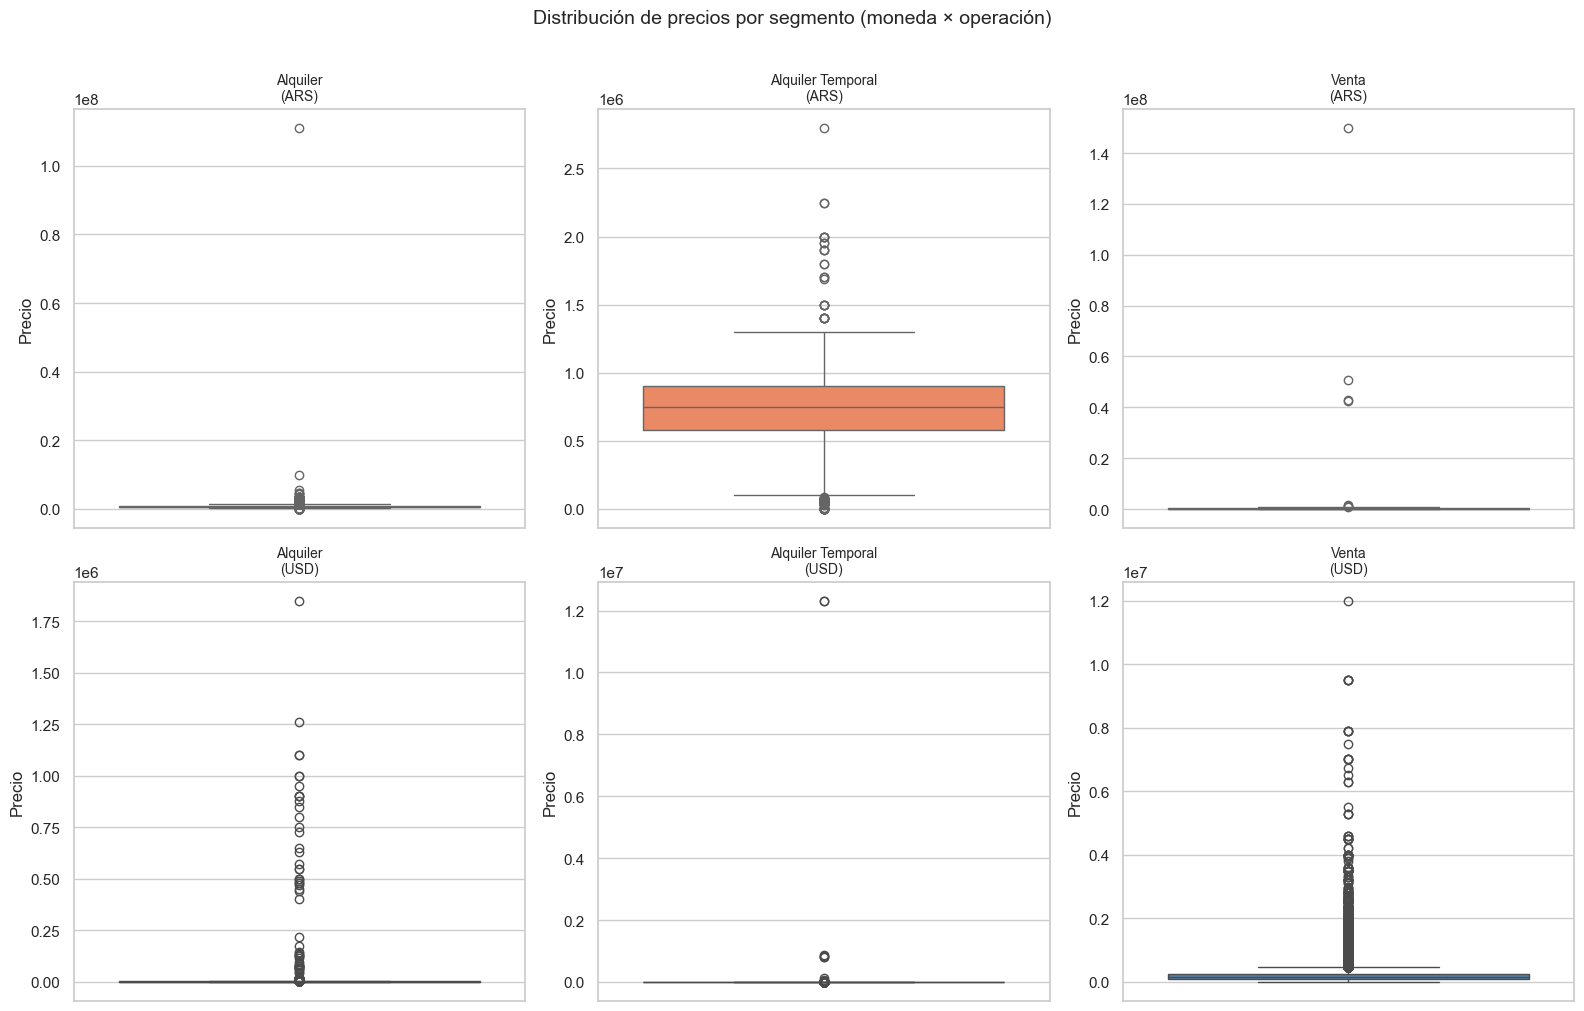

In [ ]:
df_plot = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# Definimos los segmentos a graficar
monedas = ['ars', 'usd']
operaciones = ['alquiler', 'alquiler_temporal', 'venta']

fig, axes = plt.subplots(
    nrows=len(monedas),
    ncols=len(operaciones),
    figsize=(16, 10),
    sharex=False,
    sharey=False
)

for i, moneda in enumerate(monedas):
    for j, operacion in enumerate(operaciones):
        ax = axes[i][j]
        subset = df_plot[(df_plot['moneda'] == moneda) & (df_plot['operacion'] == operacion)]['precio'].dropna()

        if len(subset) > 0:
            sns.boxplot(y=subset, ax=ax, color='steelblue' if moneda == 'usd' else 'coral')
            ax.set_title(f"{operacion.replace('_', ' ').title()}\n({moneda.upper()})", fontsize=10)
        else:
            ax.set_visible(False)

        ax.set_xlabel("")
        ax.set_ylabel("Precio")

fig.suptitle("Distribución de precios por segmento (moneda × operación)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

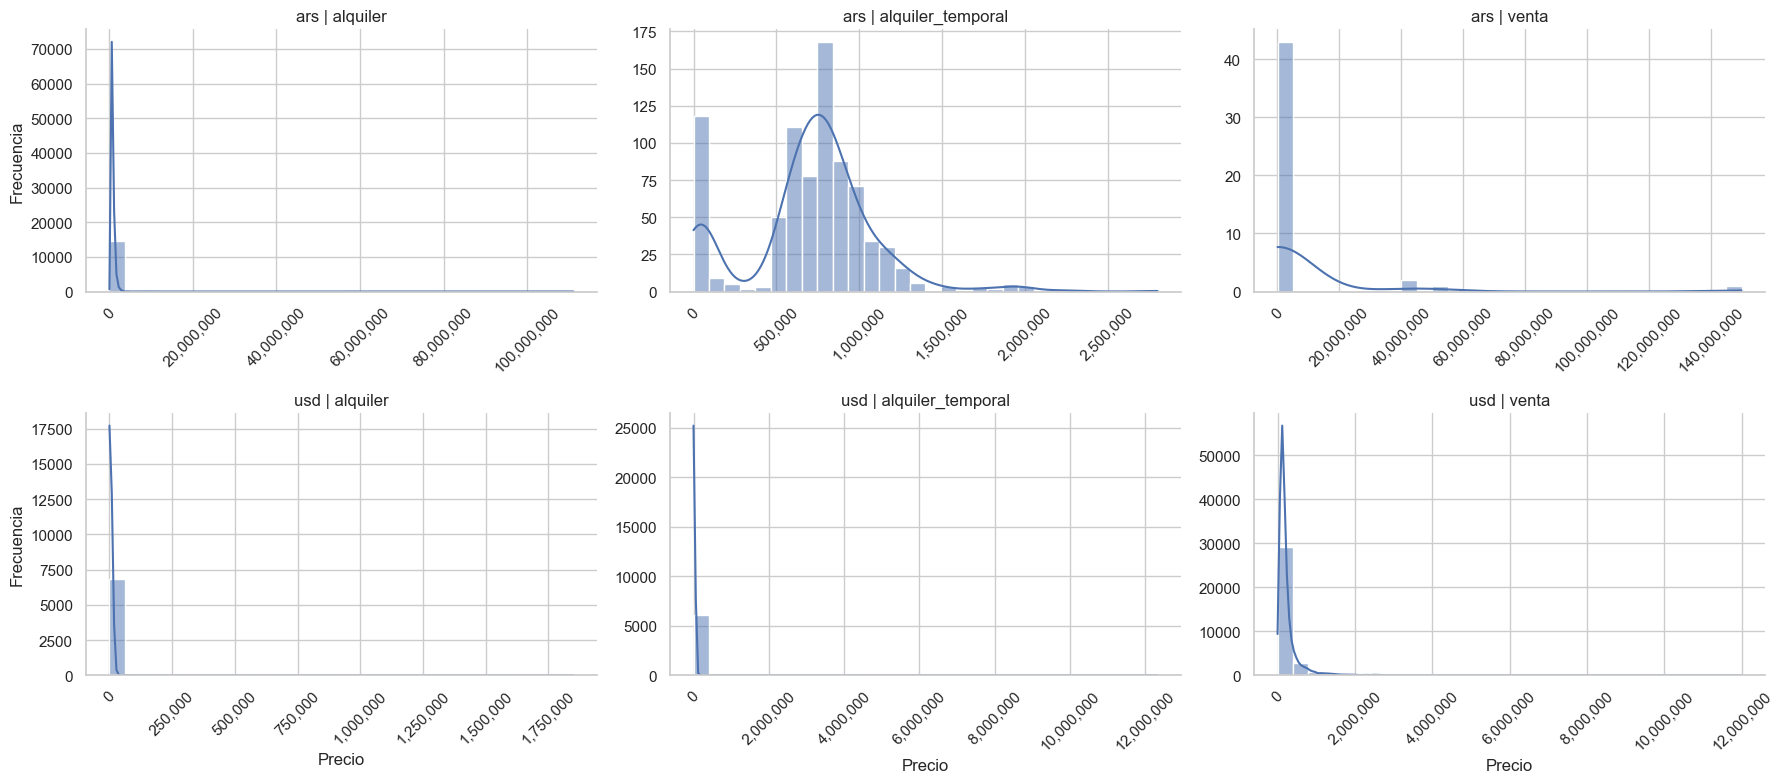

In [ ]:
import matplotlib.ticker as ticker

df_precio = df.dropna(subset=["precio", "moneda", "operacion"]).copy()

# 1. Crear el FacetGrid
g = sns.FacetGrid(df_precio, row="moneda", col="operacion", 
                  sharex=False, sharey=False, height=4, aspect=1.5)

# 2. Mapear el histograma
g.map_dataframe(sns.histplot, x="precio", bins=30, kde=True)

# 3. La magia: Ajustar cada subgráfico individualmente
for ax in g.axes.flat:
    # Quitar la notación científica (1e8, etc.)
    ax.ticklabel_format(style='plain', axis='x')
    
    # Opcional: Poner separadores de miles para que sea legible (ej: 1.000.000)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
    
    # Rotar las etiquetas si son muy largas
    ax.tick_params(axis='x', rotation=45)

g.set_axis_labels("Precio", "Frecuencia")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
plt.tight_layout()
plt.show()

En muchos de los gráficos, la gran mayoría de los registros se agrupan en una única barra cerca del cero. Esto sucede porque el eje x se extiende automáticamente para alcanzar valores extremos (posibles errores de carga o propiedades excepcionales), dejando el "mercado real" comprimido en un espacio reducido.

Además, las curvas de densidad se ven como líneas verticales que caen abruptamente, lo que impide analizar la distribución normal, la moda o la dispersión de los precios comunes.

Entonces, para obtener un análisis representativo, necesitamos aplicar técnicas de filtrado de outliers. Solo tratando estos ruidos vamos a poder ver la verdadera forma de la oferta inmobiliaria.

# 5. Feature Engineering - Parseo de texto y KPIs

Extraemos variables estructuradas a partir de las columnas de texto libre `detalles` y `descripción` mediante expresiones regulares. Luego materializamos los KPIs definidos en la entrega anterior.

In [232]:
detalles = df['detalles'].unique()
print(detalles)

['60 m² tot. 2 amb. 1 dorm. 1 baño'
 '114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.'
 '121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.' ...
 '111 m² cubie. 2 dorm. 2 baños' '90 m² cubie. 3 dorm. 27 años'
 '99 m² cubie. 2 dorm. 95 años']


Los detalles pueden incluir distintos datos, pero decidimos solo extraer m², ambientes, dormitorios, baños y antigüedad, que son las variables numericas que necesitamos. 

Las demas, las obtenemos de descripcion, como variables binarias o categoricas (si en la descripcion encontramos cada uno de los valores). 

## Funciones

In [233]:
import pandas as pd
import re

def parse_detalles(s):
    """Parsea la columna 'detalles' de ZonaProp/ArgEnProp en columnas individuales."""
    if pd.isna(s):
        return {}
    result = {}

    # Superficie total (ej: "60 m² tot." o "60 m² cubie.")
    m_tot = re.search(r'([\d,\.]+)\s*m²\s*tot\.?', s)
    m_cub = re.search(r'([\d,\.]+)\s*m²\s*cubie\.?', s)
    if m_tot:
        result['m2_total'] = float(m_tot.group(1).replace(',', '.'))
    elif m_cub:
        result['m2_total'] = float(m_cub.group(1).replace(',', '.'))

    # Ambientes (ej: "3 amb." o "3 ambientes")
    amb = re.search(r'(\d+)\s*amb\.', s)
    ambientes = re.search(r'(\d+)\s*ambientes', s)
    if amb:
        result['ambientes'] = int(amb.group(1))
    elif ambientes:
        result['ambientes'] = int(ambientes.group(1))

    # Dormitorios (ej: "2 dorm.")
    dorm = re.search(r'(\d+)\s*dorm\.', s)
    if dorm:
        result['dormitorios'] = int(dorm.group(1))

    # Baños (ej: "1 baño" o "2 baños")
    ban = re.search(r'(\d+)\s*baños?', s)
    if ban:
        result['baños'] = int(ban.group(1))
        
    # Antigüedad: 0 si "A estrenar", número si "X años"
    a_estrenar = re.search(r'A\s*[Ee]strenar', s)
    anios = re.search(r'(\d+)\s*años', s)
    if a_estrenar:
        result['antiguedad_años'] = 0
    elif anios:
        result['antiguedad_años'] = int(anios.group(1))

    return result

In [265]:
def parse_descripcion(s):
    if pd.isna(s):
        return {}
    
    s_low = s.lower()
    result = {}

    # --- Orientación ---
    if re.search(r'contra\s*frente|contrafrente', s_low):
        result['orientacion'] = 'Contra Frente'
    elif re.search(r'\bfrente\b', s_low):
        result['orientacion'] = 'Frente'
    elif re.search(r'\blateral\b', s_low):
        result['orientacion'] = 'Lateral'

    # --- Vista ---
    if re.search(r'vista\s*al?\s*r[ií]o', s_low):
        result['vista_rio'] = True
    if re.search(r'vista\s*al?\s*park|vista\s*verde|vista\s*jard[ií]n', s_low):
        result['vista_verde'] = True

    # --- Balcón ---
    if re.search(r'balc[oó]n', s_low):
        result['balcon'] = True

    # --- Terraza ---
    if re.search(r'terraza', s_low):
        result['terraza'] = True

    # --- Pileta ---
    if re.search(r'pileta|piscina', s_low):
        result['pileta'] = True

    # --- Parrilla ---
    if re.search(r'parrill[ao]', s_low):
        result['parrilla'] = True

    # --- SUM ---
    if re.search(r'\bsum\b|sal[oó]n\s*de\s*usos\s*m[uú]ltiples', s_low):
        result['sum'] = True

    # --- Laundry / Lavadero ---
    if re.search(r'laundry|lavadero', s_low):
        result['lavadero'] = True

    # --- Gimnasio ---
    if re.search(r'gimnasio|gym\b', s_low):
        result['gimnasio'] = True

    # --- Baulera ---
    if re.search(r'baulera', s_low):
        result['baulera'] = True

    # --- Calefacción ---
    if re.search(r'piso\s*radiante', s_low):
        result['calefaccion'] = 'Piso radiante'
    elif re.search(r'radiadores?', s_low):
        result['calefaccion'] = 'Radiadores'
    elif re.search(r'calefacci[oó]n\s*central', s_low):
        result['calefaccion'] = 'Central'
    elif re.search(r'calefacci[oó]n', s_low):
        result['calefaccion'] = 'Sí'

    # --- Agua caliente central ---
    if re.search(r'agua\s*caliente\s*central', s_low):
        result['agua_caliente_central'] = True

    # --- Ascensor ---
    if re.search(r'sin\s*ascensor|no\s*tiene\s*ascensor', s_low):
        result['ascensor'] = False
    elif re.search(r'ascensor', s_low):
        result['ascensor'] = True

    # --- Portero ---
    if re.search(r'portero\s*(?:el[eé]ctrico|visor|virtual)', s_low):
        result['portero'] = True


    # --- Apto profesional ---
    if re.search(r'no\s*apto\s*prof', s_low):
        result['apto_profesional'] = False
    elif re.search(r'apto\s*prof|apto\s*para\s*prof', s_low):
        result['apto_profesional'] = True

    # --- Mascotas ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:mascotas?|animales?)|no\s*mascotas?', s_low):
        result['permite_mascotas'] = 0
    elif re.search(r'acept[ao]\s*mascotas?|permite?\s*mascotas?|mascotas?\s*(?:ok|permitidas?)|apto\s*mascota', s_low):
        result['permite_mascotas'] = 1

    # --- Garantías ---
    if re.search(r'no\s*(?:se\s*)?acept[ao]\s*(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = False
    elif re.search(r'(?:seguro\s*de\s*)?cau[cs]i[oó]n', s_low):
        result['acepta_caucion'] = True
    if re.search(r'finaer', s_low):
        result['acepta_finaer'] = True

    # --- Financiación ---
    if re.search(r'financiaci[oó]n|financia\b', s_low):
        result['ofrece_financiacion'] = True

    # --- Accesibilidad ---
    if re.search(r'movilidad\s*reducida|accesible\s*para\s*personas', s_low):
        result['accesible_movilidad_reducida'] = True

    # --- Dependencia de servicio ---
    if re.search(r'dependencia\s*(?:de\s*)?servicio', s_low):
        result['dependencia_servicio'] = True

    # --- Cocina tipo ---
    if re.search(r'cocina\s*american[ao]|cocina\s*integrada|cocina\s*abierta', s_low):
        result['cocina_tipo'] = 'Americana/Integrada'
    elif re.search(r'cocina\s*independiente|cocina\s*separada', s_low):
        result['cocina_tipo'] = 'Independiente'
        
    # --- Expensas ---
    if re.search(r'expensas?\s*incluidas?|incluye\s*expensas?|sin\s*expensas?|expensas?\s*a\s*cargo\s*del\s*propietario', s_low):
        result['tiene_expensas'] = 0
    elif re.search(r'expensas?', s_low):
        result['tiene_expensas'] = 1
    else:
        result['tiene_expensas'] = 0

    return result


## Implementamos las funciones:

In [212]:
df_det = pd.DataFrame(df['detalles'].apply(parse_detalles).tolist())

In [266]:
df_desc = pd.DataFrame(df['descripción'].apply(parse_descripcion).tolist())

In [267]:
# Detalles pisa a descripcion (detalles es más confiable)
combined = df_desc.combine_first(df_det)

In [268]:
bool_cols = [
    'balcon', 'terraza', 'pileta', 'parrilla', 'sum', 'lavadero', 'gimnasio',
    'baulera', 'aire_acondicionado', 'agua_caliente_central', 'ascensor',
    'portero', 'seguridad_24hs', 'apto_profesional', 'permite_mascotas',
    'acepta_caucion', 'acepta_finaer', 'ofrece_financiacion',
    'accesible_movilidad_reducida', 'dependencia_servicio',
    'vista_rio', 'vista_verde', 'monoambiente'
]

for col in bool_cols:
    if col in combined.columns:
        combined[col] = combined[col].map({True: 1, False: 0}).fillna(0).astype(int)

In [269]:
combined.head(10)

,accesible_movilidad_reducida,acepta_caucion,acepta_finaer,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,calefaccion,cocina_tipo,dependencia_servicio,dormitorios,gimnasio,lavadero,m2_total,ofrece_financiacion,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,0,0,0,0,2,NaN,0,0,1,0,1,Sí,NaN,0,1,0,1,60,0,NaN,0,0,0,0,0,1,0,0,0
1,0,1,0,0,3,NaN,0,0,1,0,2,NaN,NaN,0,2,0,1,114,0,Contra Frente,1,0,0,0,0,1,0,0,0
2,0,0,0,0,4,NaN,0,0,1,0,2,NaN,Independiente,0,2,1,1,121,0,NaN,1,0,1,0,0,0,0,0,0
3,0,0,0,0,2,NaN,1,0,1,0,1,NaN,Americana/Integrada,0,1,0,0,66,0,Frente,0,0,0,0,0,1,1,0,0
4,0,0,0,0,3,NaN,0,0,0,0,2,NaN,NaN,0,2,1,0,117,0,NaN,0,0,1,0,0,0,1,0,0
5,0,0,0,1,1,NaN,0,0,0,0,1,NaN,NaN,0,1,0,1,30,0,NaN,1,0,0,0,0,0,1,0,0
6,0,0,0,0,2,NaN,0,0,0,0,1,NaN,Independiente,0,1,0,0,40,0,NaN,0,0,0,0,0,0,1,0,0
7,0,0,0,0,4,NaN,0,0,0,0,2,NaN,NaN,1,3,0,0,148,0,Frente,0,0,0,0,0,0,1,0,0
8,0,0,0,0,2,NaN,0,0,1,0,1,NaN,NaN,0,1,1,1,67,0,Frente,1,0,1,0,0,0,0,0,0
9,0,0,0,1,1,NaN,1,0,1,0,1,NaN,NaN,0,1,0,0,43,0,Frente,0,0,0,0,0,0,0,0,0


Agrego las nuevas variables al df:

In [380]:
df_final = pd.concat([df, combined], axis=1)
df_final.head()

,fecha_scraping,posting_id,sitio,operacion,precio,expensas,calle,altura,piso,barrio,detalles,descripción,link,amenities,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_norm,barrio_oficial,moneda,accesible_movilidad_reducida,...,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,calefaccion,cocina_tipo,dependencia_servicio,dormitorios,gimnasio,lavadero,m2_total,ofrece_financiacion,orientacion,parrilla,permite_mascotas,pileta,portero,sum,terraza,tiene_expensas,vista_rio,vista_verde
0,2026-04-12,58757240,zonaprop,alquiler,"750,000","300,000",Mansilla,"2,936",NaN,Barrio Norte,60 m² tot. 2 amb. 1 dorm. 1 baño,Amplio departamento de dos ambientes en el exc...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,0,0,1,0,Barrio Norte,Recoleta,ars,0,...,2,NaN,0,0,1,0,1,Sí,NaN,0,1,0,1,60,0,NaN,0,0,0,0,0,1,0,0,0
1,2026-04-12,58818211,zonaprop,alquiler,"1,700,000","400,000",Cespedes,"2,300",NaN,Belgrano,114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,"3 ambientes con balcón, y terraza con parrilla...",https://www.zonaprop.com.ar/propiedades/clasif...,1,0,0,0,1,0,0,0,Belgrano,Belgrano,ars,0,...,3,NaN,0,0,1,0,2,NaN,NaN,0,2,0,1,114,0,Contra Frente,1,0,0,0,0,1,0,0,0
2,2026-04-12,58564550,zonaprop,alquiler,"2,500","1,150,000",Riobamba,"1,200",NaN,Recoleta,121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.,Departamento en alquiler de 4 ambientes con co...,https://www.zonaprop.com.ar/propiedades/clasif...,4,0,0,0,1,1,1,0,Recoleta,Recoleta,usd,0,...,4,NaN,0,0,1,0,2,NaN,Independiente,0,2,1,1,121,0,NaN,1,0,1,0,0,0,0,0,0
3,2026-04-12,58314210,zonaprop,alquiler,"1,300",NaN,Pereyra Lucena,"2,500",NaN,Palermo,66 m² tot. 2 amb. 1 dorm. 1 baño,Amoblado y Equipado. Ubicado a metros de Av. L...,https://www.zonaprop.com.ar/propiedades/clasif...,0,0,0,0,1,0,1,1,Palermo,Palermo,usd,0,...,2,NaN,1,0,1,0,1,NaN,Americana/Integrada,0,1,0,0,66,0,Frente,0,0,0,0,0,1,1,0,0
4,2026-04-12,58810878,zonaprop,alquiler,"3,800",NaN,Lola Mora,400,NaN,Puerto Madero,117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.,Alquiler temporario de 3 ambientes amueblado e...,https://www.zonaprop.com.ar/propiedades/clasif...,3,0,0,0,1,1,0,0,Puerto Madero,Puerto Madero,usd,0,...,3,NaN,0,0,0,0,2,NaN,NaN,0,2,1,0,117,0,NaN,0,0,1,0,0,0,1,0,0


# 6. Tratamiento de expensas

Las expensas deberían estar expresadas en pesos argentinos. Sin embargo, es posible que algunos valores estén en dólares o sean valores inusualmente bajos que no corresponden a la realidad del mercado de 2026 en Buenos Aires. El siguiente análisis busca detectar valores sospechosos que podrían indicar errores de carga o valores en otra moneda.

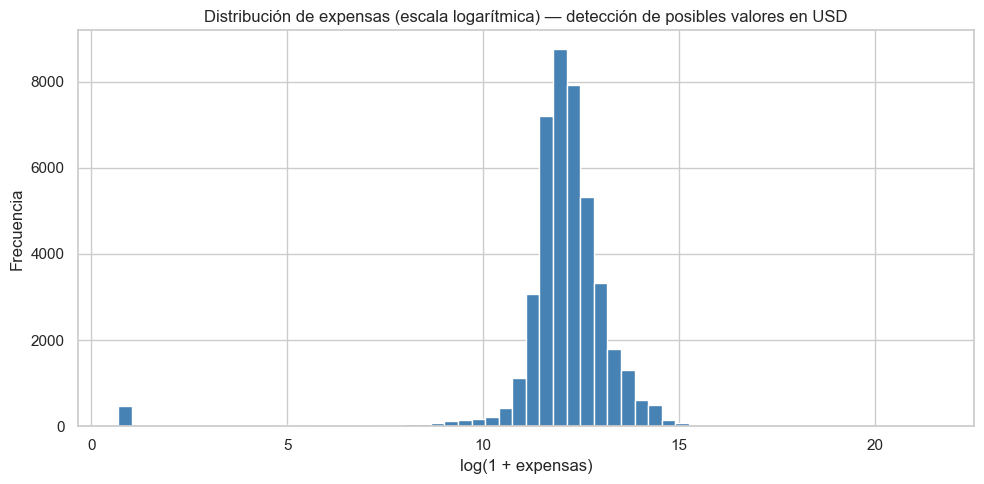

In [273]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_final['expensas'].dropna()
ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
plt.tight_layout()
plt.show()

Vemos que hay un grupo de valores con expensas muy bajas, entonces usamos el grafico del codo para buscar donde esta el corte:

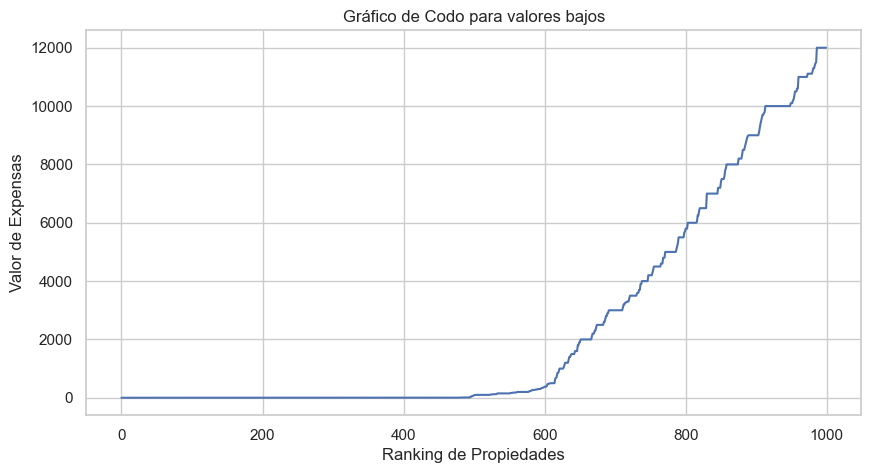

In [274]:
# Ordenamos los valores de menor a mayor
expensas_ordenadas = df_final['expensas'].dropna().sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(expensas_ordenadas[:1000]) # Miramos los primeros 500 registros más bajos
plt.ylabel("Valor de Expensas")
plt.xlabel("Ranking de Propiedades")
plt.title("Gráfico de Codo para valores bajos")
plt.show()

En este grafico vemos que hasta la propiedad número 500 aproximadamente, el valor es 0, por lo que son departamentos sin expensas. Despues, entre la propiedad 500 y la 600, la línea empieza a despegarse pero muy lentamente, son valores insignificantes (1, 10, 100 pesos). Vamos a considerar estos valores, como numeros que la gente puso para representar que no hay expensas.

Entonces, el verdadero "salto" de mercado, donde la pendiente se vuelve empinada y constante, empieza alrededor de la propiedad 600, que coincide con valores superiores a los $2.000 - $3.000. Ahí es donde pondremos nuestro umbral.

## TODO: VER SI ESTO TIENE SENTIDO. SI ESTA BIEN, CAMBIAR DE DF_PRUEBA AL DF_FINAL

In [275]:
df_prueba = df_final.copy()

In [276]:
import numpy as np

# Definimos el cutoff basado en el gráfico de codo
umbral_basura = 100
umbral_minimo_mercado = 4000 

# Creamos una columna nueva para no perder la original por si queremos comparar
df_prueba['expensas_ok'] = df_prueba['expensas']

# Aplicamos la lógica que dedujimos del gráfico
df_prueba.loc[df_prueba['expensas'] < umbral_basura, 'expensas_ok'] = 0
mask_error = (df_prueba['expensas'] >= umbral_basura) & (df_prueba['expensas'] < umbral_minimo_mercado)
df_prueba.loc[mask_error, 'expensas_ok'] = np.nan

# Calculamos estadisticas...
# ...sobre la columna limpia:
resumen_expensas_ok = df_prueba.groupby('operacion')['expensas_ok'].agg(
    count='count',         # Aquí verás que el count baja porque los errores ahora son NaN
    media='mean',          # La media debería subir
    mediana='median',      # La mediana será más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("Resumen de expensas LIMPIAS:")
print(resumen_expensas_ok)

# ...sobre la columna original:
resumen_expensas_og = df_prueba.groupby('operacion')['expensas'].agg(
    count='count',         # Aquí verás que el count baja porque los errores ahora son NaN
    media='mean',          # La media debería subir
    mediana='median',      # La mediana será más realista
    p5=lambda x: x.quantile(0.05)
).round(0)

print("\nResumen de expensas ORIGINALES:")
print(resumen_expensas_og)

# Verificamos si quedan sospechosos despues de la limpieza
sospechosos_nuevos = df_prueba[
    (df_prueba['expensas_ok'] > 0) & 
    (df_prueba['expensas_ok'] < umbral_minimo_mercado)
]['expensas_ok']

print(f"\nSospechosos en columna limpia: {len(sospechosos_nuevos)}")

# RESUMEN FINAL
# 1. Cuántos eran menores a 100 (convertidos a 0)
cant_a_cero = len(df_prueba[(df_prueba['expensas'] < 100)])

# 2. Cuántos eran "ruido" (convertidos a NaN)
# Estos son los que el análisis de codo nos dijo que eran errores
cant_a_nan = len(df_prueba[(df_prueba['expensas'] >= 100) & (df_prueba['expensas'] < 4000)])

# 3. Resumen total
total_registros = len(df_prueba)

print(f"\n--- Auditoría de Limpieza de Expensas ---")
print(f"Total de registros analizados: {total_registros}")
print(f"Registros llevados a 0 (sin expensas): {cant_a_cero}")
print(f"Registros anulados (ruido/errores): {cant_a_nan}")
print(f"Total de datos modificados: {cant_a_cero + cant_a_nan}")
print(f"Porcentaje de datos 'sucios' eliminados: {((cant_a_nan / total_registros) * 100):.2f}%")

Resumen de expensas LIMPIAS:
                   count   media  mediana     p5
operacion                                       
alquiler           17902 525,461  180,000 75,000
alquiler_temporal   2972 205,321  154,124 15,000
venta              21990 300,591  190,000 45,500

Resumen de expensas ORIGINALES:
                   count   media  mediana     p5
operacion                                       
alquiler           17977 523,271  180,000 74,000
alquiler_temporal   3009 202,799  150,000    540
venta              22113 298,931  187,200 40,000

Sospechosos en columna limpia: 0

--- Auditoría de Limpieza de Expensas ---
Total de registros analizados: 62937
Registros llevados a 0 (sin expensas): 503
Registros anulados (ruido/errores): 235
Total de datos modificados: 738
Porcentaje de datos 'sucios' eliminados: 0.37%


Revisamos como quedo:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


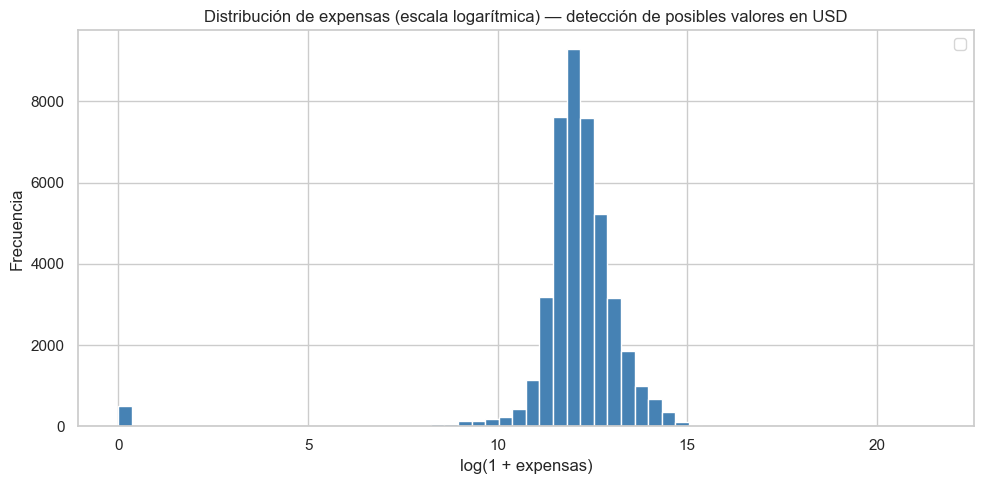

In [277]:
# Histograma de expensas en escala logarítmica para detectar anomalías
fig, ax = plt.subplots(figsize=(10, 5))

expensas_validas = df_prueba['expensas_ok'].dropna()

ax.hist(np.log1p(expensas_validas), bins=60, color='steelblue', edgecolor='white')
ax.set_xlabel("log(1 + expensas)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de expensas (escala logarítmica) — detección de posibles valores en USD")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Estadísticas resumen de expensas por tipo de operación
# resumen_expensas = df.groupby('operacion')['expensas'].agg(
#     count='count',
#     media='mean',
#     mediana='median',
#     p5=lambda x: x.quantile(0.05),
#     p95=lambda x: x.quantile(0.95)
# ).round(0)

# print("Resumen de expensas por tipo de operación:")
# print(resumen_expensas)

# Valores sospechosamente bajos: menos de 1000 ARS en 2026 es prácticamente imposible
# TODO: por que este valor arbitrario de 1000 ARS? podria ser mas alto, no se puede hacer algun analisis para ver donde seria el cutoff point?
# umbral_sospechoso = 1000
# sospechosos = df[df['expensas'] < umbral_sospechoso]['expensas'].dropna()
# print(f"\nExpensas con valor menor a ${umbral_sospechoso} ARS (posibles errores o valores en USD): {len(sospechosos)}")
# if len(sospechosos) > 0:
#     print("Ejemplos:")
#     print(df[df['expensas'] < umbral_sospechoso][['operacion', 'precio', 'moneda', 'expensas']].head(10))

Resumen de expensas por tipo de operación:
                   count     media   mediana       p5       p95
operacion                                                      
alquiler           17977  523271.0  180000.0  74000.0  750000.0
alquiler_temporal   3009  202799.0  150000.0    540.0  500000.0
venta              22113  298931.0  187200.0  40000.0  900000.0

Expensas con valor menor a $1000 ARS (posibles errores o valores en USD): 621
Ejemplos:
     operacion     precio moneda  expensas
356   alquiler     2800.0    usd     250.0
386   alquiler     1500.0    usd       1.0
527   alquiler     3700.0    usd       1.0
585   alquiler     4100.0    usd       1.0
646   alquiler     4600.0    usd      10.0
745   alquiler     2200.0    usd       1.0
796   alquiler     1000.0    usd     380.0
804   alquiler   600000.0    ars       1.0
953   alquiler  1000000.0    ars       1.0
1034  alquiler  1000000.0    ars       1.0


# 7. Valores faltantes:

## Inspeccionamos:

Vemos como se estructuran los valores faltantes que tenemos:

In [327]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
       Variable  Datos_Faltantes  Porcentaje
         precio             1494           2
       expensas            19838          32
          calle             5370           9
         altura             5370           9
           piso            49314          78
       detalles              220           0
    descripción              293           0
 barrio_oficial                3           0
      ambientes            30464          48
antiguedad_años            37387          59
          baños            21414          34
    calefaccion            50844          81
    cocina_tipo            42540          68
    dormitorios            13624          22
       m2_total             2436           4
    orientacion            30324          48
 tiene_expensas              293           0


Muchos de los valores faltante provienen de las columnas que agregamos en el parse, tanto de detalle como de descripcion. Vemos los valores faltantes, separando por sitio: tal vez los datos de zonaprop tienen detalles distintos a los de argenprop.

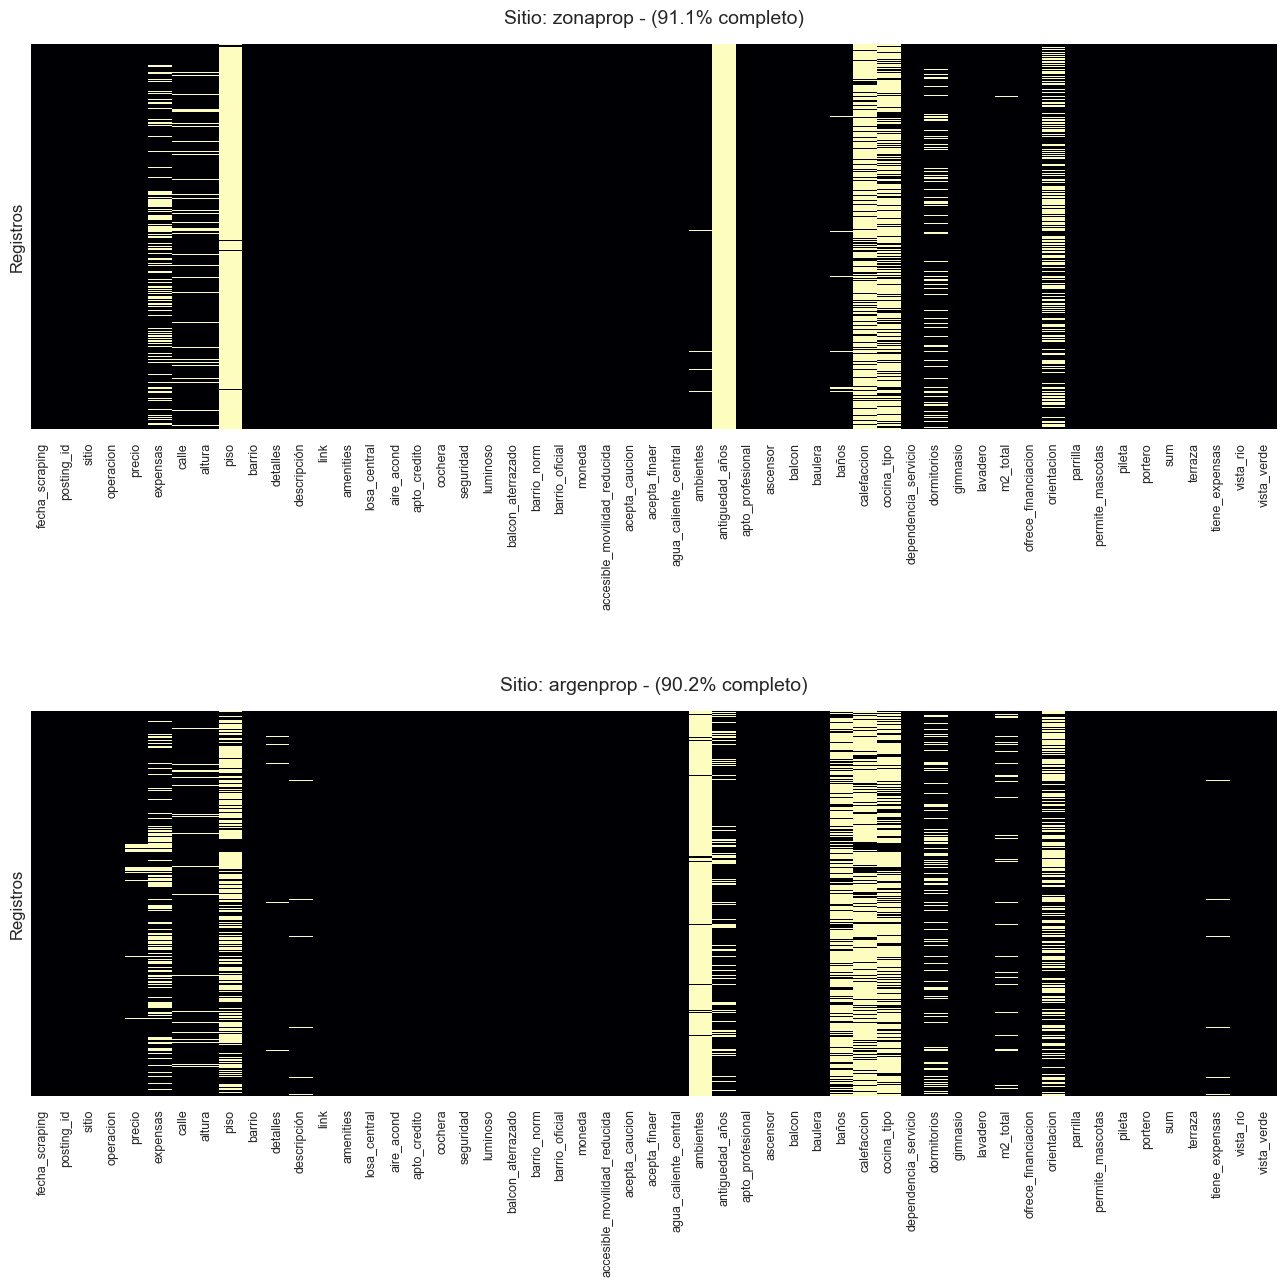

In [368]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

# Aumentamos un poco el ancho (14) para que las columnas respiren
fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    # cmap='magma' suele resaltar mejor los nulos (amarillo sobre negro/morado)
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    # --- AQUÍ ESTÁ EL TRUCO PARA EL EJE X ---
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    # Forzamos que se muestren TODAS las etiquetas
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Efectivamente, podemos ver que variables como ambientes y baños estan practicamente completas en zonaprop, y practicamente vacias en argenprop; antigüedad_años esta vacia en zonaprop, pero mucho mas completa en argenprop. Vemos como se compone detalles:

In [329]:
df_final[df_final['sitio']=='zonaprop']['detalles']

0                  60 m² tot. 2 amb. 1 dorm. 1 baño
1        114 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
2        121 m² tot. 4 amb. 2 dorm. 2 baños 1 coch.
3                  66 m² tot. 2 amb. 1 dorm. 1 baño
4        117 m² tot. 3 amb. 2 dorm. 2 baños 1 coch.
                            ...                    
31745           150 m² tot. 2 dorm. 2 baños 1 coch.
31746              51 m² tot. 2 amb. 1 dorm. 1 baño
31747              77 m² tot. 3 amb. 2 dorm. 1 baño
31748    169 m² tot. 4 amb. 3 dorm. 2 baños 2 coch.
31749             80 m² tot. 3 amb. 2 dorm. 2 baños
Name: detalles, Length: 31750, dtype: object

In [330]:
df_final[df_final['sitio']=='argenprop']['detalles']

31750         47 m² cubie. Monoam. Bueno
31751       80 m² cubie. 2 dorm. 15 años
31752      100 m² cubie. 2 dorm. 40 años
31753        27 m² cubie. 1 baño Monoam.
31754       34 m² cubie. 1 dorm. 80 años
                      ...               
62932       63 m² cubie. 2 dorm. 30 años
62933        25 m² cubie. 40 años 1 baño
62934    60 m² cubie. 1 dorm. A Estrenar
62935       65 m² cubie. 2 dorm. 15 años
62936       62 m² cubie. 3 dorm. 50 años
Name: detalles, Length: 31187, dtype: object

Podemos ver reflejadas esas diferencias.

Igualmente, tambien hay variables a las que le faltan muchos valores en ambos, que pueden faltar desde el scraper (como calle, altura y piso), o del parse de descripcion (como calefaccion, cocina_tipo y orientación).

Entonces, teniendo esto cuenta, vamos a utilizar distintas tecnicas para tratar los valores faltantes.

## Tratamos los valores faltantes

### Expensas:

Para tratar las expensas, vamos a utilizar la variable tiene_expensas, que construimos a partir del parse de descripción. Si el valor es faltante, y tiene_expensas es 0, imputamos un 0; pero si tiene_expensas es 1, utilizamos el precio y el barrio para imputar el valor.

In [381]:
# 1. Creamos segmentos de precio (deciles) para que la imputación sea lógica
# Usamos qcut para que cada grupo tenga la misma cantidad de deptos
df_final['segmento_precio'] = pd.qcut(df_final['precio'], q=10, labels=False, duplicates='drop')

# 2. Aplicamos la imputación condicional de expensas
# Primero: Si 'tiene_expensas' es 0, el valor es 0
df_final.loc[df_final['tiene_expensas'] == 0, 'expensas'] = 0

# Segundo: Para los que 'tiene_expensas' es 1 pero el valor es NaN
# Imputamos por la mediana de su BARRIO y su SEGMENTO DE PRECIO
df_final['expensas'] = df_final.groupby(['barrio', 'segmento_precio'])['expensas'].transform(
    lambda x: x.fillna(x.median())
)

# Tercero: Si aún quedan nulos (barrios con pocos datos en ese segmento), 
# usamos solo el segmento de precio a nivel general
df_final['expensas'] = df_final.groupby('segmento_precio')['expensas'].transform(
    lambda x: x.fillna(x.median())
)

# Si todavia quedan nulos, usamos la mediana general de todo el dataset para que NO quede ni un solo nulo
df_final['expensas'].fillna(df_final['expensas'].median(), inplace=True)

# Borramos la columna auxiliar para que no ensucie el modelo
df_final.drop(columns=['segmento_precio'], inplace=True)

### Ambientes, baños, dormitorio, antigüedad:

Como estas variables se encuentran mas que nada en uno de los sitios, usamos los datos del otro sitio como base, para imputar los valores:

In [382]:
# 1. Crear rangos de m2 para que la imputación sea coherente
df_final['m2_bin'] = pd.qcut(df_final['m2_total'], q=10, duplicates='drop')

# 2. Lista de variables estructurales a salvar
vars_estructurales = ['ambientes', 'baños', 'dormitorios', 'antiguedad_años']

for col in vars_estructurales:
    # Imputamos por la mediana del Barrio Y el Rango de M2
    df_final[col] = df_final.groupby(['barrio', 'm2_bin'])[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavía quedan nulos (porque ese bin en ese barrio está vacío), usamos solo el bin
    df_final[col] = df_final.groupby('m2_bin')[col].transform(lambda x: x.fillna(x.median()))
    
    # Si todavia quedan nulos, usamos la mediana general de todo el dataset para que NO quede ni un solo nulo
    df_final[col].fillna(df_final[col].median(), inplace=True)


# 4. Limpieza final de columnas descartadas
df_final.drop(columns='m2_bin', inplace=True, errors='ignore')

### Otras:

Finalmente, las que tienen un numero demasiado alto de valores faltantes, y no son pertinentes para nuestro analisis, las eliminamos:

In [383]:
cols_descarte = ['calle', 'altura', 'piso', 'calefaccion', 'cocina_tipo', 'orientacion']
df_final.drop(columns=cols_descarte, inplace=True, errors='ignore')

## Revisamos como quedo:

In [384]:
missing_info = df_final.isnull().sum()
missing_percent = (df_final.isnull().sum() / len(df_final)) * 100

print("Variables con datos faltantes:")
missing_summary = pd.DataFrame({
    'Variable': missing_info.index,
    'Datos_Faltantes': missing_info.values,
    'Porcentaje': missing_percent.values
})
missing_summary = missing_summary[missing_summary['Datos_Faltantes'] > 0]
print(missing_summary.to_string(index=False))

Variables con datos faltantes:
      Variable  Datos_Faltantes  Porcentaje
        precio             1494           2
      detalles              220           0
   descripción              293           0
barrio_oficial                3           0
      m2_total             2436           4
tiene_expensas              293           0


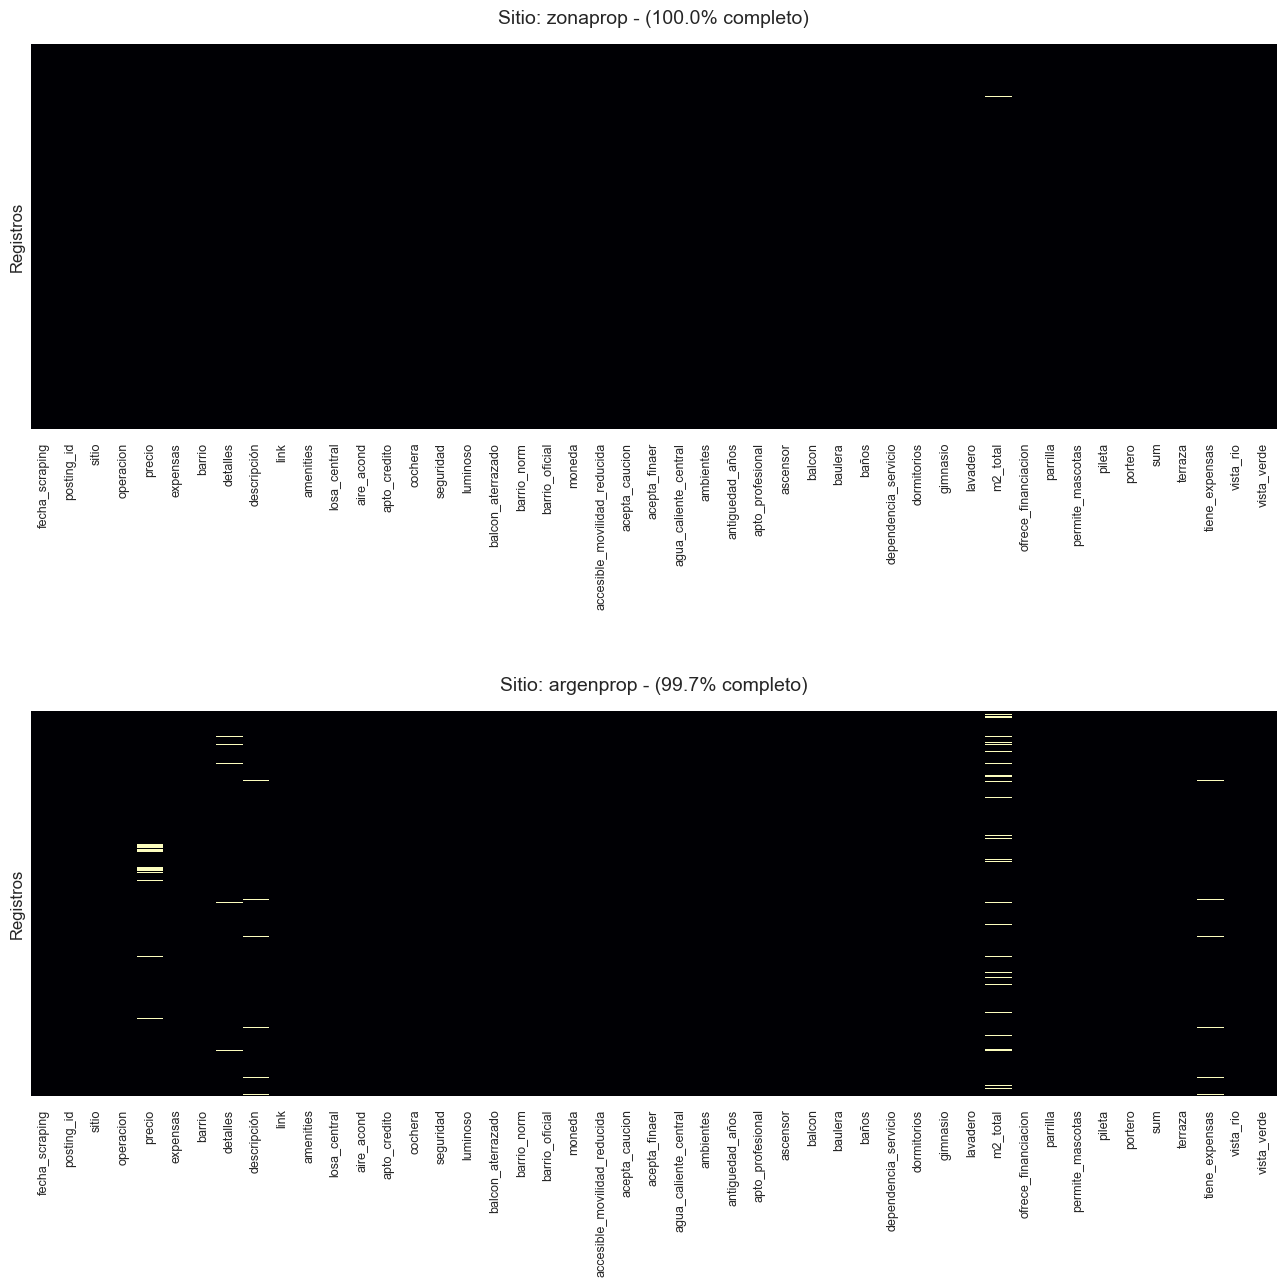

In [339]:
import matplotlib.pyplot as plt
import seaborn as sns

sitios = df_final['sitio'].unique()
n_sitios = len(sitios)

# Aumentamos un poco el ancho (14) para que las columnas respiren
fig, axes = plt.subplots(n_sitios, 1, figsize=(14, 7 * n_sitios))

if n_sitios == 1:
    axes = [axes]

for i, sitio in enumerate(sitios):
    df_sitio = df_final[df_final['sitio'] == sitio]
    
    # cmap='magma' suele resaltar mejor los nulos (amarillo sobre negro/morado)
    sns.heatmap(df_sitio.isnull(), cbar=False, ax=axes[i], yticklabels=False, cmap='magma')
    
    # --- AQUÍ ESTÁ EL TRUCO PARA EL EJE X ---
    axes[i].set_xticklabels(axes[i].get_xticklabels(), 
                            rotation=90, 
                            horizontalalignment='center', 
                            fontsize=9)
    
    # Forzamos que se muestren TODAS las etiquetas
    axes[i].set_xticks(np.arange(len(df_sitio.columns)) + 0.5)
    
    total_celdas = df_sitio.size
    nulos = df_sitio.isnull().sum().sum()
    completitud = 100 * (1 - nulos/total_celdas)
    
    axes[i].set_title(f'Sitio: {sitio} - ({completitud:.1f}% completo)', fontsize=14, pad=15)
    axes[i].set_ylabel('Registros')

plt.tight_layout(pad=4.0)
plt.show()

Finalmente, borramos los registros de lo pocos datos faltantes que quedan, ya que son muy pocos, y no vale la pena imputarlos: los de precio y m2 es importante que sean reales; y los de detalle, descripcion son imposibles (e innecesarios) de completar.

In [385]:
# 1. Eliminamos registros sin las variables fundamentales (Precio y Metros)
# Es mejor perder un 4% de datos que tener datos inventados en el core
df_final.dropna(subset=['precio', 'm2_total', 'barrio_oficial'], inplace=True)

# 2. Eliminamos registros sin descripción o detalles
# Sin esto no pudimos haber hecho el feature engineering correctamente
df_final.dropna(subset=['descripción', 'detalles'], inplace=True)

# 3. Verificamos que no quede NADA nulo en estas columnas
print("Nulos después de la limpieza final:")
print(df_final.isnull().sum())

Nulos después de la limpieza final:
fecha_scraping                  0
posting_id                      0
sitio                           0
operacion                       0
precio                          0
expensas                        0
barrio                          0
detalles                        0
descripción                     0
link                            0
amenities                       0
losa_central                    0
aire_acond                      0
apto_credito                    0
cochera                         0
seguridad                       0
luminoso                        0
balcon_aterrazado               0
barrio_norm                     0
barrio_oficial                  0
moneda                          0
accesible_movilidad_reducida    0
acepta_caucion                  0
acepta_finaer                   0
agua_caliente_central           0
ambientes                       0
antiguedad_años                 0
apto_profesional                0
ascensor    

# 8. Tratamiento de Outliers (con precio_por_m2):

## Paso 1 - Imports

In [281]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 50)

## Paso 2 - Calcular precio_por_m²

Usamos precio_por_m² como KPI central en lugar del precio total porque permite comparar propiedades de distintos tamaños dentro del mismo barrio. Sin esta normalización, un PH de 200m² siempre va a parecer outlier por precio total aunque sea perfectamente normal por m².

Filtramos antes de calcular para no propagar NaN ni divisiones inválidas.

Revisamos valores muy bajos de m², que puedan haber sido cargados mal, para saber donde cortar:

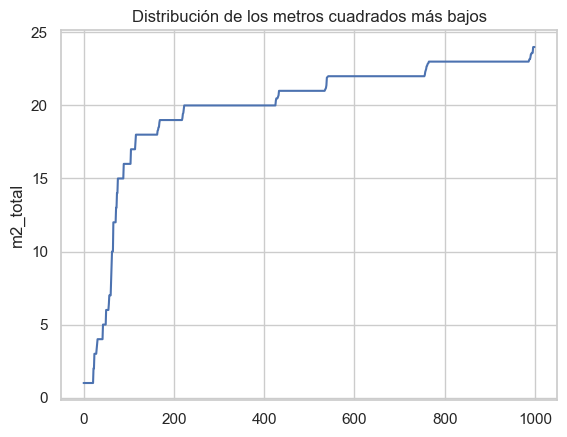

In [282]:
df_prueba = df_final.copy()

# Graficamos el "codo" de los metros cuadrados
plt.plot(df_prueba['m2_total'].sort_values().reset_index(drop=True)[:1000])
plt.title("Distribución de los metros cuadrados más bajos")
plt.ylabel("m2_total")
plt.show()

Podemos ver que por debajo de 15 hay algunos departamento, aunque no tienen sentido lógico. A partir de 15, aumenta claramente la cantidad de departamentos, por lo que probablemente los anteriores sean un error de carga. Por lo que los filtramos antes de calcular precio_por_m2:

In [386]:
mask_m2 = (
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 15) & # filtramos los de menos de 15m²
    df_final['precio'].notna() &
    (df_final['precio'] > 0)
)

df_final['precio_por_m2'] = np.nan
df_final.loc[mask_m2, 'precio_por_m2'] = (
    df_final.loc[mask_m2, 'precio'] / df_final.loc[mask_m2, 'm2_total']
)

print(f"Con precio_por_m2: {mask_m2.sum():,} de {len(df_final):,} ({mask_m2.mean()*100:.1f}%)")

# Nos quedamos solo con registros que tienen precio_por_m2 calculado
df_final = df_final[df_final['precio_por_m2'].notna()].copy()
print(f"Registros con precio_por_m2 válido: {len(df_final):,}")

Con precio_por_m2: 58,742 de 58,823 (99.9%)
Registros con precio_por_m2 válido: 58,742


Nos quedamos con los que se puede calcular precio_por_m2, ya que es una metrica sumamente importante.

## Paso 3 - Deduplicar scraping

Al scrapear, el mismo aviso podria aparecer más de una vez. Deduplicamos por posting_id + sitio, no por características de la propiedad (barrio, precio, m²), porque dos inmuebles distintos pueden coincidir en esas columnas y no son duplicados.

In [387]:
n_antes = len(df_final)
df_final = df_final.drop_duplicates(subset=['posting_id', 'sitio'], keep='first').copy()

n_eliminados = n_antes - len(df_final)
print(f"Duplicados de scraping eliminados: {n_eliminados:,} ({n_eliminados/n_antes*100:.1f}%)")
print(f"Registros restantes: {len(df_final):,}")

assert df_final.duplicated(subset=['posting_id', 'sitio']).sum() == 0, "Todavía hay duplicados!"

Duplicados de scraping eliminados: 5,016 (8.5%)
Registros restantes: 53,726


Eliminamos el 8.5% de los registros duplicados

## Paso 4 - Corrección de errores de moneda

Existe una dependencia circular entre detección de moneda y análisis de outliers: si un precio en USD fue clasificado como ARS por error, va a aparecer como valor extremadamente bajo dentro del segmento ARS. Si no lo corregimos antes, puede sobrevivir los filtros de outliers cuando en realidad es un error de clasificación.

Primero graficamos la distribución de precios ARS para elegir los umbrales con criterio visual, luego reclasificamos.

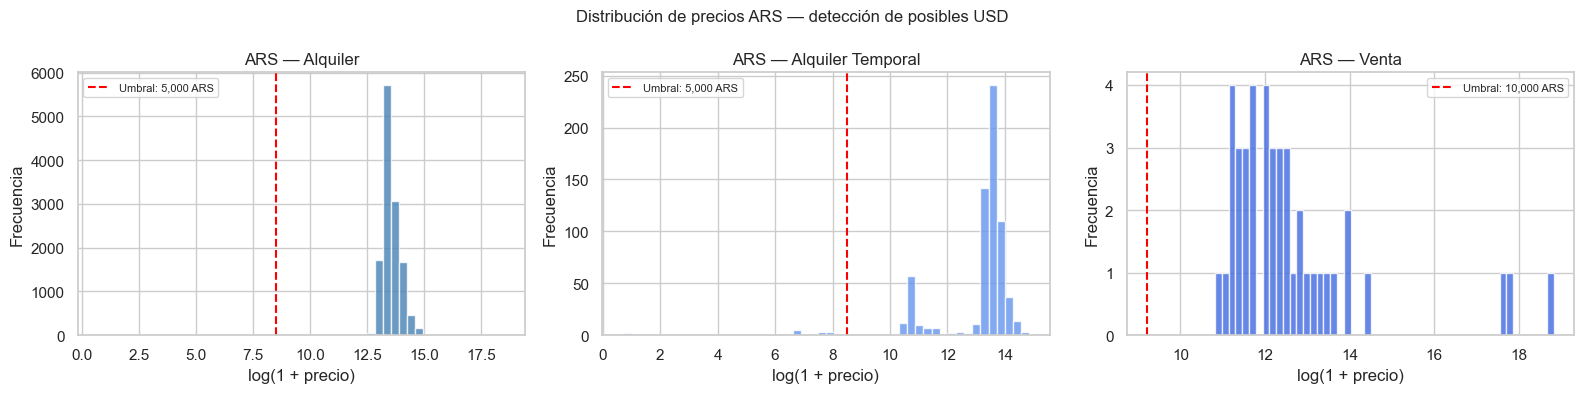

Registros ARS por debajo del umbral (candidatos a reclasificar):
  alquiler: 25 registros con precio < 5,000 ARS
  alquiler_temporal: 18 registros con precio < 5,000 ARS
  venta: 0 registros con precio < 10,000 ARS


In [388]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribución de precios ARS — detección de posibles USD', fontsize=12)

ops      = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 5_000, 'alquiler_temporal': 5_000, 'venta': 10_000}
colores  = ['steelblue', 'cornflowerblue', 'royalblue']

for ax, op, color in zip(axes, ops, colores):
    subset = df_final[
        (df_final['moneda'] == 'ars') & (df_final['operacion'] == op)
    ]['precio'].dropna()

    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(
        np.log1p(umbrales[op]),
        color='red', linestyle='--',
        label=f'Umbral: {umbrales[op]:,} ARS'
    )
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel('log(1 + precio)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Registros ARS por debajo del umbral (candidatos a reclasificar):")
for op, umbral in umbrales.items():
    n = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    ).sum()
    print(f"  {op}: {n} registros con precio < {umbral:,} ARS")

Un alquiler ARS < 5.000 pesos en 2026 es imposible → probablemente USD

Una venta ARS < 10.000 pesos en 2026 es imposible → probablemente USD

Entonces:

In [389]:
UMBRALES_IMPOSIBLES_ARS = {
    'alquiler':           5_000,
    'alquiler_temporal':  5_000,
    'venta':             10_000,
}

n_reclasificados = 0
for op, umbral in UMBRALES_IMPOSIBLES_ARS.items():
    mask = (
        (df_final['moneda'] == 'ars') &
        (df_final['operacion'] == op) &
        (df_final['precio'] < umbral)
    )
    n_reclasificados += mask.sum()
    df_final.loc[mask, 'moneda'] = 'usd'
    print(f"  Reclasificados '{op}': {mask.sum()} registros")

print(f"\nTotal reclasificados ARS → USD: {n_reclasificados}")

  Reclasificados 'alquiler': 25 registros
  Reclasificados 'alquiler_temporal': 18 registros
  Reclasificados 'venta': 0 registros

Total reclasificados ARS → USD: 43


Ahora, probamos algo similar, pero en los alquileres que tienen valores en dolares demasiado grandes, que probablemente sean pesos:

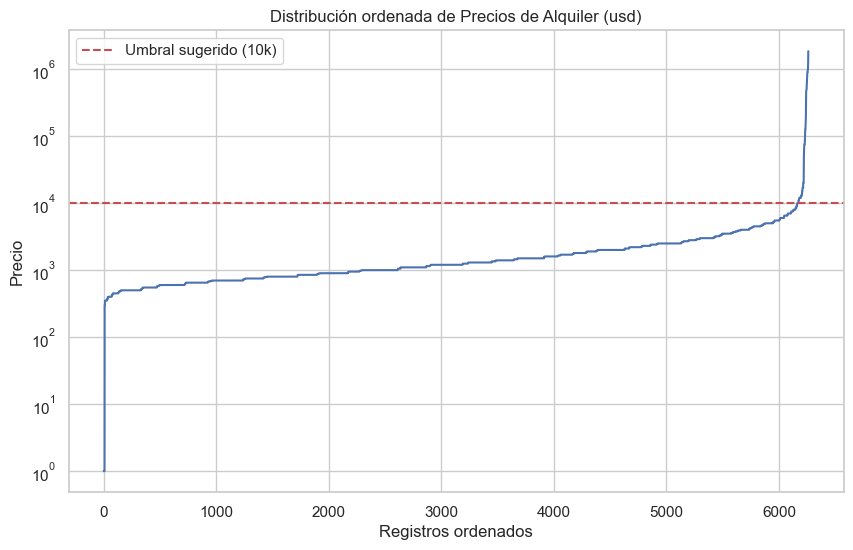

In [425]:
import numpy as np

# 1. Filtramos y ordenamos los precios de alquiler en usd
alquileres_usd = df_final[(df_final['operacion'] == 'alquiler') & 
                          (df_final['moneda'] == 'usd')]['precio'].sort_values().reset_index(drop=True)

# 2. Graficamos para ver el "Codo"
plt.figure(figsize=(10, 6))
plt.plot(alquileres_usd.values)
plt.axhline(y=10000, color='r', linestyle='--', label='Umbral sugerido (10k)')
plt.title('Distribución ordenada de Precios de Alquiler (usd)')
plt.ylabel('Precio')
plt.xlabel('Registros ordenados')
plt.yscale('log') # Usamos escala logarítmica para ver mejor el quiebre
plt.legend()
plt.show()

Vemos que a partir de 10000, hay unos pocos registros que tienen valores demasiados altos, para ser dolares. Por lo cual definimos este como nuestro umbral

In [427]:
# Usamos el umbral que definimos:
umbral_usd = 10000

# 1. Identificamos los registros sospechosos: Alquiler + USD + Precio > Umbral
mask_sospechosos = (df_final['operacion'] == 'alquiler') & \
                   (df_final['moneda'] == 'usd') & \
                   (df_final['precio'] > umbral_usd)

print(mask_sospechosos.sum())

# 2. A estos sospechosos les cambiamos la moneda a ARS internamente
df_final.loc[mask_sospechosos, 'moneda'] = 'ars'

print(f"Se corrigieron {mask_sospechosos.sum()} registros de alquiler que estaban mal etiquetados como USD.")

88
Se corrigieron 88 registros de alquiler que estaban mal etiquetados como USD.


## Paso 5 - Filtros absolutos

Eliminamos valores que son imposibles en cualquier contexto del mercado. Estos errores contaminarían el cálculo de percentiles si los dejamos adentro, por eso se aplican antes del paso de Winsorización.

La diferencia con el paso anterior es que allá corregíamos la moneda; acá directamente eliminamos registros que no tienen sentido en ningún segmento.

In [428]:
PISO_USD_ALQUILER = 5        # USD/m² — imposible en cualquier barrio de CABA
PISO_USD_VENTA    = 400      # USD/m² — por debajo → casi seguro error de moneda
PISO_ARS_ALQUILER = 3_000    # ARS/m² — mínimo razonable post-corrección
TECHO_USD_M2      = 25_000   # USD/m² - por encima → error de tipeo

mask_error = (
    # ventas USD con precio ridículo
    ((df_final['operacion'] == 'venta') &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_VENTA))
    |
    # alquileres USD imposibles
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'usd') &
     (df_final['precio_por_m2'] < PISO_USD_ALQUILER))
    |
    # alquileres ARS imposibles
    ((df_final['operacion'].isin(['alquiler', 'alquiler_temporal'])) &
     (df_final['moneda'] == 'ars') &
     (df_final['precio_por_m2'] < PISO_ARS_ALQUILER))
    |
    # techo absoluto global
    (df_final['precio_por_m2'] > TECHO_USD_M2)
)

print(f"Eliminados por filtros absolutos: {mask_error.sum():,}")
df_final = df_final[~mask_error].copy()
print(f"Registros restantes: {len(df_final):,}")

Eliminados por filtros absolutos: 939
Registros restantes: 52,787


## Paso 6 - Percentiles adaptativos + Winsorización

Para los valores extremos que sí existen en el mercado (propiedades de lujo, PHs grandes), Winsorizamos en lugar de eliminar: reemplazamos el valor extremo por el límite del percentil, conservando el registro con todas sus features para el modelo.

El percentil es adaptativo por segmento: calculamos P1-P99 por operacion + moneda + barrio. Si el barrio tiene menos de 30 registros, usamos operacion + moneda como fallback para que el percentil sea estadísticamente válido.

Esto es importante porque Villa Lugano y Puerto Madero tienen rangos de precios completamente distintos: un percentil global trataría como outlier propiedades perfectamente normales en cada uno.

In [429]:
N_MIN         = 30     # mínimo de registros para usar percentil por barrio
SEG_FINO      = ['operacion', 'moneda', 'barrio_oficial']
SEG_GRUESO    = ['operacion', 'moneda']
Q_LOW, Q_HIGH = 0.01, 0.99


def calcular_percentiles_adaptativos(df, col, seg_fino, seg_grueso, q_low, q_high, n_min):
    """Calcula percentiles por segmento fino; usa segmento grueso si n < n_min."""
    df = df.copy()

    stats_fino = (
        df.groupby(seg_fino)[col]
        .agg(
            n      = 'count',
            p_low  = lambda x: x.quantile(q_low),
            p_high = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )
    stats_grueso = (
        df.groupby(seg_grueso)[col]
        .agg(
            p_low_fb  = lambda x: x.quantile(q_low),
            p_high_fb = lambda x: x.quantile(q_high)
        )
        .reset_index()
    )

    df = df.merge(stats_fino,   on=seg_fino,   how='left')
    df = df.merge(stats_grueso, on=seg_grueso, how='left')

    df['p_low']  = np.where(df['n'] >= n_min, df['p_low'],  df['p_low_fb'])
    df['p_high'] = np.where(df['n'] >= n_min, df['p_high'], df['p_high_fb'])

    return df.drop(columns=['n', 'p_low_fb', 'p_high_fb'])


df_final = calcular_percentiles_adaptativos(
    df_final, 'precio_por_m2',
    SEG_FINO, SEG_GRUESO,
    Q_LOW, Q_HIGH, N_MIN
)

# Guardar el valor original para referencia y para el paso siguiente
df_final['precio_por_m2_original'] = df_final['precio_por_m2'].copy()

# Winsorizar: reemplazar por el límite en lugar de eliminar
mask_sup = df_final['precio_por_m2'] > df_final['p_high']
mask_inf = df_final['precio_por_m2'] < df_final['p_low']

df_final.loc[mask_sup, 'precio_por_m2'] = df_final.loc[mask_sup, 'p_high']
df_final.loc[mask_inf, 'precio_por_m2'] = df_final.loc[mask_inf, 'p_low']

print(f"Winsorizados por encima del P{Q_HIGH*100:.0f}: {mask_sup.sum():,}")
print(f"Winsorizados por debajo del P{Q_LOW*100:.0f}:  {mask_inf.sum():,}")
print(f"Total winsorizados: {(mask_sup | mask_inf).sum():,} ({(mask_sup | mask_inf).mean()*100:.1f}%)")

df_final = df_final.drop(columns=['p_low', 'p_high'])

Winsorizados por encima del P99: 517
Winsorizados por debajo del P1:  579
Total winsorizados: 1,096 (2.1%)


Ya que es solo el 2.1%, podemos imputarles los valores del limite del percentil, sin modificar notablemente la distribución de la variables.

## Paso 7 - Alquiler temporal ARS: precios por noche

El alquiler temporal en ARS mezcla precios por noche con precios por mes. Un depto de 35m² a 600 ARS no es un outlier, es 600 ARS por noche, equivalente a aprox. 18.000 ARS/m² mensual, perfectamente razonable.

Estos registros no se Winsorizan porque el problema no es un valor extremo sino una unidad de tiempo incompatible: no existe forma de convertirlos sin saber si el precio es por noche, por semana o por mes. Se eliminan directamente.

In [430]:
UMBRAL_NOCHE_ARS = 2_000   # ARS/m² implícito; por debajo → precio por noche

mask_at_ars    = (
    (df_final['operacion'] == 'alquiler_temporal') &
    (df_final['moneda'] == 'ars')
)
mask_por_noche = mask_at_ars & (df_final['precio_por_m2_original'] < UMBRAL_NOCHE_ARS)

print(f"Alquiler temporal ARS por noche (eliminados): {mask_por_noche.sum()}")
print(f"Alquiler temporal ARS por mes  (conservados): {(mask_at_ars & ~mask_por_noche).sum()}")

df_final = df_final[~mask_por_noche].copy()

Alquiler temporal ARS por noche (eliminados): 0
Alquiler temporal ARS por mes  (conservados): 433


## Paso 8 - Features de zona

Segmentamos los barrios en tres categorías que el modelo puede usar como feature. Puerto Madero funciona como un mercado aparte (precios 2-3x la media), y los barrios populares tienen un piso de precios sistemáticamente más bajo.

En lugar de eliminar estos registros, los marcamos para que el modelo aprenda el efecto de zona explícitamente.

In [431]:
# Ajustá estas listas según tu conocimiento del mercado
BARRIOS_PREMIUM   = ['Puerto Madero']
BARRIOS_POPULARES = [
    'Villa Lugano', 'Villa Riachuelo', 'Villa Soldati',
    'Mataderos', 'Liniers', 'Parque Patricios'
]

df_final['segmento_zona'] = np.where(
    df_final['barrio_oficial'].isin(BARRIOS_PREMIUM),    'premium',
    np.where(
        df_final['barrio_oficial'].isin(BARRIOS_POPULARES), 'popular',
        'estandar'
    )
)

print("Distribución por segmento de zona:")
print(df_final['segmento_zona'].value_counts())

print("\nMediana precio/m² por zona (venta USD):")
print(
    df_final[df_final['operacion'] == 'venta']
    .groupby('segmento_zona')['precio_por_m2']
    .agg(['count', 'median', 'min', 'max'])
    .round(0)
)

Distribución por segmento de zona:
segmento_zona
estandar    49618
premium      1868
popular      1301
Name: count, dtype: int64

Mediana precio/m² por zona (venta USD):
               count  median   min    max
segmento_zona                            
estandar       27109   2,551   560  9,253
popular          962   1,851   645  3,731
premium          579   5,676 3,368 16,471


## Paso 9 - Consolidar segmentos con poco volumen

Algunos combos operacion + moneda + segmento_zona quedaron con muy pocos registros (ej: alquiler USD popular con n=4). Usar estos como categoría en el modelo genera overfitting: el modelo aprende el ruido de esos pocos registros en lugar del patrón real.

Colapsamos los segmentos pequeños a estandar para que el modelo los trate junto con el grupo mayoritario.

In [432]:
N_MIN_SEG = 30

conteo = df_final.groupby(
    ['operacion', 'moneda', 'segmento_zona']
)['precio_por_m2'].transform('count')

df_final['segmento_zona_modelo'] = np.where(
    conteo < N_MIN_SEG,
    'estandar',
    df_final['segmento_zona']
)

print("Distribución final segmento_zona_modelo:")
print(
    df_final.groupby(['operacion', 'moneda', 'segmento_zona_modelo'])
    .size()
    .to_frame('n')
)

Distribución final segmento_zona_modelo:
                                                   n
operacion         moneda segmento_zona_modelo       
alquiler          ars    estandar              11998
                         popular                 326
                  usd    estandar               5166
                         premium                 990
alquiler_temporal ars    estandar                433
                  usd    estandar               4934
                         premium                 290
venta             ars    estandar                 40
                  usd    estandar              27071
                         popular                 961
                         premium                 578


## Paso 10 - Transformación logarítmica

Los precios inmobiliarios tienen distribución log-normal: la diferencia relativa entre 50.000 y 100.000 USD es equivalente a la diferencia entre 200.000 y 400.000 USD. El logaritmo captura esta relación y estabiliza la varianza.

Usamos log1p(x) = log(1 + x) en lugar de log(x) porque es numéricamente estable para valores cercanos a 0 y es invertible con expm1() para recuperar la escala original.

In [433]:
df_final['log_precio']    = np.log1p(df_final['precio'])
df_final['log_m2']        = np.log1p(df_final['m2_total'])
df_final['log_precio_m2'] = np.log1p(df_final['precio_por_m2'])

print("Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2")

Variables logarítmicas creadas: log_precio, log_m2, log_precio_m2


## Paso 11 - Reporte y validación final

Verificamos que no hayan quedado NaN ni infinitos en las variables clave, y revisamos que los rangos por segmento sean coherentes con el mercado.

Nota sobre el gráfico: los puntos fuera de los bigotes del boxplot son normales. Seaborn marca como outlier cualquier punto más allá de 1.5×IQR, que es un criterio más estricto que nuestro P1-P99. No son errores, son los extremos reales del mercado dentro del rango que definimos como válido.

DATASET FINAL: 52,787 registros
OK — sin NaN ni infinitos en variables clave

Distribución por segmento:
                                                   n     p5  mediana    p95
operacion         moneda segmento_zona_modelo                              
alquiler          ars    estandar              11998 11,392   16,949 23,214
                         popular                 326 10,000   14,623 20,249
                  usd    estandar               5166     10       18     33
                         premium                 990     18       26     46
alquiler_temporal ars    estandar                433 11,632   19,000 24,707
                  usd    estandar               4934     10       18     32
                         premium                 290     18       29     53
venta             ars    estandar                 40  1,394    3,431  5,987
                  usd    estandar              27071  1,415    2,551  4,610
                         popular                 961    850

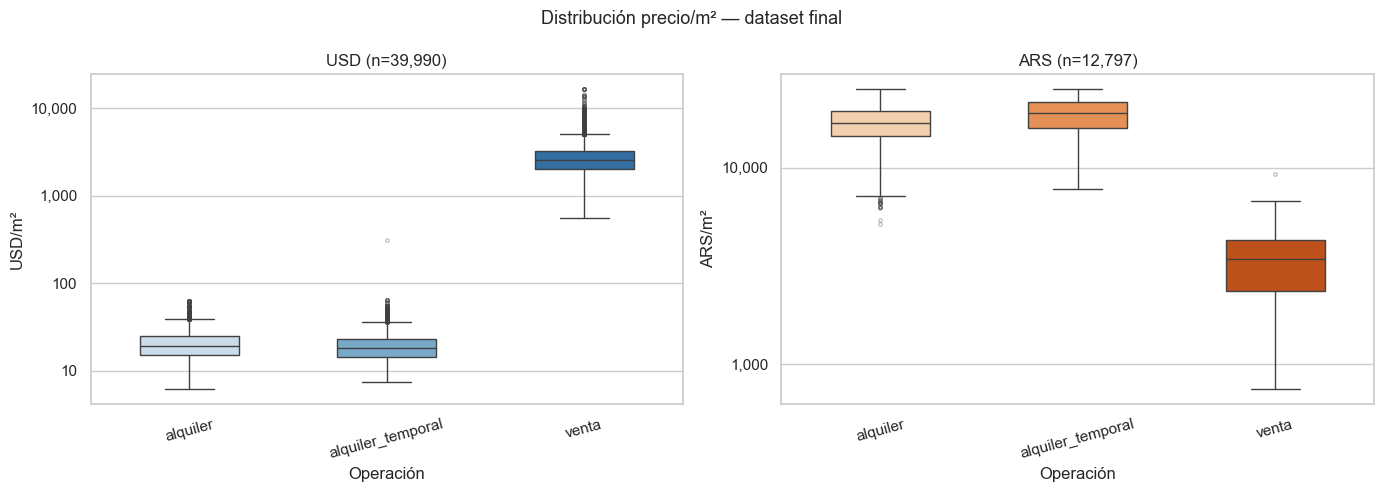

In [434]:
print("=" * 55)
print(f"DATASET FINAL: {len(df_final):,} registros")
print("=" * 55)

# Sanidad: no deben quedar NaN ni infinitos en variables clave
vars_clave = ['precio', 'm2_total', 'precio_por_m2',
              'log_precio', 'log_m2', 'log_precio_m2']
nans = df_final[vars_clave].isna().sum()
infs = (df_final[vars_clave] == np.inf).sum()
assert nans.sum() == 0, f"Hay NaN:\n{nans[nans > 0]}"
assert infs.sum() == 0, f"Hay infinitos:\n{infs[infs > 0]}"
print("OK — sin NaN ni infinitos en variables clave")

# Distribución por segmento
print("\nDistribución por segmento:")
resumen = (
    df_final
    .groupby(['operacion', 'moneda', 'segmento_zona_modelo'])['precio_por_m2']
    .agg(
        n       = 'count',
        p5      = lambda x: x.quantile(0.05),
        mediana = 'median',
        p95     = lambda x: x.quantile(0.95)
    )
    .round(0)
)
print(resumen)

# Gráfico con escala logarítmica en el eje Y para legibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución precio/m² — dataset final', fontsize=13)

for ax, (moneda, palette) in zip(axes, [('usd', 'Blues'), ('ars', 'Oranges')]):
    datos = df_final[df_final['moneda'] == moneda]
    sns.boxplot(
        x='operacion', y='precio_por_m2',
        data=datos, ax=ax,
        palette=palette, width=0.5,
        flierprops=dict(marker='.', markersize=5, alpha=0.3)
    )
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_title(f'{moneda.upper()} (n={len(datos):,})')
    ax.set_xlabel('Operación')
    ax.set_ylabel(f'{moneda.upper()}/m²')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# Reconocimiento de outliers (ver con cual nos quedamos)

## Corrección de Moneda por Análisis de Valores

Existe una dependencia circular entre la detección de moneda y el análisis de outliers: si un precio en USD fue clasificado como ARS por error, aparecerá como un valor extremadamente bajo dentro del segmento ARS y podría ser tratado como outlier cuando en realidad no lo es.

Para romper este ciclo, realizamos una corrección de moneda **antes** del análisis de outliers: identificamos precios etiquetados como ARS que son estadísticamente imposibles en el mercado argentino de 2026 y los reclasificamos como USD.

### Paso 1 - Diagnóstico visual: distribución de precios ARS por operación

Graficamos los precios clasificados como ARS para alquiler y venta por separado. Si existen valores extremadamente bajos (por ejemplo, alquileres de menos de 5.000 ARS), es muy probable que sean precios en USD que el parser de texto no detectó.

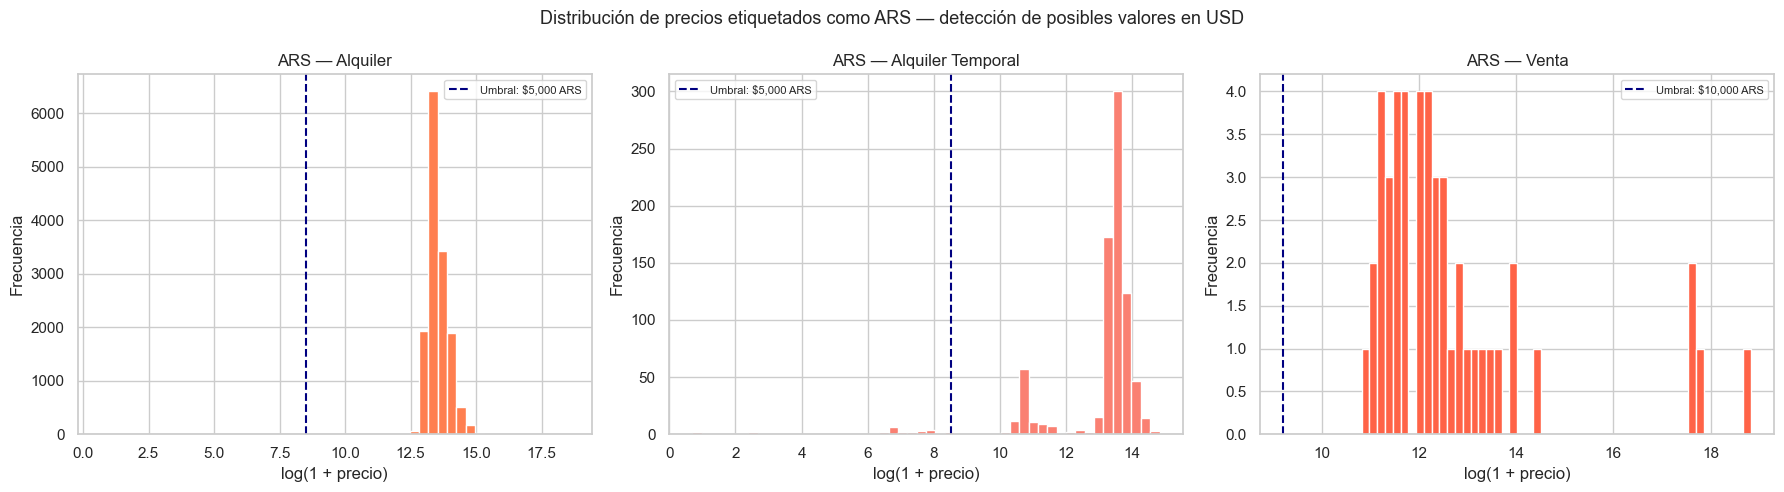

Precios ARS en 'alquiler' menores a $5,000: 28 registros
Precios ARS en 'alquiler_temporal' menores a $5,000: 26 registros
Precios ARS en 'venta' menores a $10,000: 0 registros


In [ ]:
# Diagnóstico visual: precios ARS por operación
# TODO: los umbrales no deberian ser arbitrarios, deberia ser un analisis estadistico para encontrar el cutoff point
# quizas una regresion para ver si tiene sentido ese precio de los inmuebles en esa moneda
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ops = ['alquiler', 'alquiler_temporal', 'venta']
umbrales = {'alquiler': 5000, 'alquiler_temporal': 5000, 'venta': 10000}
colores = ['coral', 'salmon', 'tomato']

for ax, op, color in zip(axes, ops, colores):
    subset = df[(df['moneda'] == 'ars') & (df['operacion'] == op)]['precio'].dropna()
    ax.hist(np.log1p(subset), bins=50, color=color, edgecolor='white')
    umbral = umbrales[op]
    ax.axvline(np.log1p(umbral), color='navy', linestyle='--', label=f'Umbral: ${umbral:,} ARS')
    ax.set_title(f"ARS — {op.replace('_', ' ').title()}")
    ax.set_xlabel("log(1 + precio)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

fig.suptitle("Distribución de precios etiquetados como ARS — detección de posibles valores en USD", fontsize=13)
plt.tight_layout()
plt.show()

# Cuántos valores están por debajo de los umbrales
for op, umbral in umbrales.items():
    n = ((df['moneda'] == 'ars') & (df['operacion'] == op) & (df['precio'] < umbral)).sum()
    print(f"Precios ARS en '{op}' menores a ${umbral:,}: {n} registros")

### Paso 2 - Reclasificación heurística

Los precios en ARS menores a los umbrales definidos son estadísticamente imposibles en el mercado argentino de 2026 y probablemente corresponden a valores en USD que no fueron detectados por el parser de texto. Los reclasificamos como USD.

In [ ]:
# Reclasificación de moneda basada en umbrales de precio
# Un alquiler ARS < 5.000 pesos en 2026 es imposible -> es USD
# Una venta ARS < 10.000 pesos en 2026 es imposible -> es USD

condiciones_reclasificacion = [
    (df['operacion'] == 'alquiler',           5_000),
    (df['operacion'] == 'alquiler_temporal',  5_000),
    (df['operacion'] == 'venta',             10_000),
]

total_reclasificados = 0
for mascara_op, umbral in condiciones_reclasificacion:
    mascara = mascara_op & (df['moneda'] == 'ars') & (df['precio'] < umbral)
    n = mascara.sum()
    total_reclasificados += n
    df.loc[mascara, 'moneda'] = 'usd'
    operacion_nombre = df.loc[mascara_op, 'operacion'].iloc[0] if mascara_op.any() else '?'
    print(f"Reclasificados en '{operacion_nombre}' (precio ARS < {umbral:,}): {n} registros")

print(f"\nTotal de registros reclasificados de ARS a USD: {total_reclasificados}")

Reclasificados en 'alquiler' (precio ARS < 5,000): 28 registros
Reclasificados en 'alquiler_temporal' (precio ARS < 5,000): 26 registros
Reclasificados en 'venta' (precio ARS < 10,000): 0 registros

Total de registros reclasificados de ARS a USD: 54


### Paso 3 - Resumen post-corrección

Comparamos la distribución de monedas antes y después de la reclasificación.

In [ ]:
# Resumen de moneda por operación luego de la reclasificación
resumen_moneda_corregido = df.groupby(["moneda", "operacion"])["precio"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
print("Resumen de precios por moneda y operación (post-corrección):")
resumen_moneda_corregido

Resumen de precios por moneda y operación (post-corrección):


count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14430  8.298803e+05  700000.0  9.968844e+05   
       alquiler_temporal    784  7.358542e+05  750000.0  3.684490e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6907  5.329785e+03    1200.0  5.359108e+04   
       alquiler_temporal   6091  5.726098e+03     850.0  2.242539e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler            7000.0  111111111.0  
       alquiler_temporal   5500.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      1.0   12322222.0  
       venta                  1.0   12000000.0

In [ ]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda 

count          mean    median           std  \
moneda operacion                                                        
ars    alquiler           14430  8.298803e+05  700000.0  9.968844e+05   
       alquiler_temporal    784  7.358542e+05  750000.0  3.684490e+05   
       venta                 47  6.357208e+06  200000.0  2.414848e+07   
usd    alquiler            6907  5.329785e+03    1200.0  5.359108e+04   
       alquiler_temporal   6091  5.726098e+03     850.0  2.242539e+05   
       venta              33184  2.428972e+05  148000.0  3.647445e+05   

                              min          max  
moneda operacion                                
ars    alquiler            7000.0  111111111.0  
       alquiler_temporal   5500.0    2800000.0  
       venta              50000.0  150000000.0  
usd    alquiler               1.0    1850000.0  
       alquiler_temporal      1.0   12322222.0  
       venta                  1.0   12000000.0

Las escalas para los tipos de monedas y tipos de operaciones son diferentes. Por eso, para analizar a los outliers, vamos a separar la base en los distintos casos. También vamos a analizar los outliers según el tipo de moneda ya que los mercados en pesos Argentinos y en Dólares son distintos. 

In [ ]:
df_venta_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "venta")].copy() #Ignoramos las ventas en pesos porque son muy pocos registros (47)
df_alquiler_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler")].copy()
df_alquiler_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler")].copy()
df_alquilertemp_usd = df[(df["moneda"] == "usd") & (df["operacion"] == "alquiler_temporal")].copy()
df_alquilertemp_ars = df[(df["moneda"] == "ars") & (df["operacion"] == "alquiler_temporal")].copy()


Utilizamos jarque berra para analizar normalidad

In [ ]:
from scipy.stats import jarque_bera

dfs = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd,
    "df_alquilertemp_ars": df_alquilertemp_ars
}

for nombre, df_temp in dfs.items():
    serie = df_temp["precio"].dropna()

    print(f"\n--- {nombre} ---")
    print(f"n = {len(serie)}")

    if len(serie) < 3:
        print("No hay suficientes datos para aplicar Jarque-Bera.")
        continue

    stat, p = jarque_bera(serie)

    print(f"Estadístico Jarque-Bera: {stat:.4f}")
    print(f"p-valor: {p:.4f}")


--- df_venta_usd ---
n = 33184
Estadístico Jarque-Bera: 36543339.4858
p-valor: 0.0000

--- df_alquiler_usd ---
n = 6907
Estadístico Jarque-Bera: 53818716.9484
p-valor: 0.0000

--- df_alquiler_ars ---
n = 14430
Estadístico Jarque-Bera: 64781931777.5644
p-valor: 0.0000

--- df_alquilertemp_usd ---
n = 6091
Estadístico Jarque-Bera: 2265496424.0846
p-valor: 0.0000

--- df_alquilertemp_ars ---
n = 784
Estadístico Jarque-Bera: 259.4620
p-valor: 0.0000


Como el p valor es pequeño, rechazamos normalidad. Verificamos que ninguna columna de precio tenga valores menores a 0 antes de aplicar Box-Cox.

In [ ]:
for nombre, df_temp in dfs.items():
    print(f"{nombre}: {(df_temp['precio'] <= 0).sum()}")

df_venta_usd: 0
df_alquiler_usd: 0
df_alquiler_ars: 0
df_alquilertemp_usd: 0
df_alquilertemp_ars: 0


Aplicamos Box Cox y luego utilizamos Tukey para detectar los outliers

In [ ]:
from scipy.stats import boxcox

def tukey_outliers(series):
    serie_valida = series.dropna()
    q1 = np.percentile(serie_valida, 25)
    q3 = np.percentile(serie_valida, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

lambdas = {}
        
for nombre, df_temp in dfs.items():
    print(f"\n{nombre}")
    
    mask_validos = df_temp["precio"].notna() & (df_temp["precio"] > 0)
    
    if mask_validos.sum() < 2:
        print("No hay suficientes valores válidos")
        continue
      
    data_bc, lambda_bc = boxcox(df_temp.loc[mask_validos, "precio"])
    lambdas[nombre] = lambda_bc
    df_temp["boxcox"] = np.nan
    df_temp.loc[mask_validos, "boxcox"] = data_bc
    
    df_temp["outlier_boxcox"] = tukey_outliers(df_temp["boxcox"])
    
    n_outliers = df_temp["outlier_boxcox"].sum()
    print(f"Outliers: {n_outliers}")
    print(f"Porcentaje: {n_outliers / mask_validos.sum() * 100:.2f}%")  # sobre válidos, no total




df_venta_usd
Outliers: 767
Porcentaje: 2.31%

df_alquiler_usd
Outliers: 105
Porcentaje: 1.52%

df_alquiler_ars
Outliers: 406
Porcentaje: 2.81%

df_alquilertemp_usd
Outliers: 171
Porcentaje: 2.81%

df_alquilertemp_ars
Outliers: 128
Porcentaje: 16.33%


Como podemos ver, en general hay un porcentaje bajo de outliers a través de cada combinación operación-moneda. Por ende, vamos a realizar imputación mediante Winsor (reemplazar mediante el límite superior o inferior) para mantener la distribución de los datos. 

De todas formas, no vamos a aplicarle este procedimiento a los alquileres temporarios en ARS, ya que este presenta una cantidad más alta de outliers (18%)

In [ ]:
dfs2 = {
    "df_venta_usd": df_venta_usd,
    "df_alquiler_usd": df_alquiler_usd,
    "df_alquiler_ars": df_alquiler_ars,
    "df_alquilertemp_usd": df_alquilertemp_usd
}

from scipy.special import inv_boxcox

for nombre, df_temp in dfs2.items():
    mask_validos = df_temp["boxcox"].notna()
    serie_bc = df_temp.loc[mask_validos, "boxcox"]
    
    q1 = np.percentile(serie_bc, 25)
    q3 = np.percentile(serie_bc, 75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    
    # Copiamos precio original
    df_temp["precio_imputado"] = df_temp["precio"].copy()
    
    # Solo tocamos las filas donde outlier_boxcox == True
    mask_outlier = df_temp["outlier_boxcox"] == True
    
    boxcox_clippeado = df_temp.loc[mask_outlier, "boxcox"].clip(lower=lim_inf, upper=lim_sup)
    df_temp.loc[mask_outlier, "precio_imputado"] = inv_boxcox(boxcox_clippeado, lambdas[nombre])
    
    print(f"{nombre}: {mask_outlier.sum()} outliers imputados")
    print(f"  precio original (outliers):   {df_temp.loc[mask_outlier, 'precio'].values[:5]}")
    print(f"  precio imputado (outliers):   {df_temp.loc[mask_outlier, 'precio_imputado'].values[:5]}\n")

df_venta_usd: 767 outliers imputados
  precio original (outliers):   [4500000. 2100000. 1445900. 3500000. 2147000.]
  precio imputado (outliers):   [1138385.42202289 1138385.42202289 1138385.42202289 1138385.42202289
 1138385.42202289]

df_alquiler_usd: 105 outliers imputados
  precio original (outliers):   [12000. 20000. 11800. 12000. 12500.]
  precio imputado (outliers):   [11697.37537901 11697.37537901 11697.37537901 11697.37537901
 11697.37537901]

df_alquiler_ars: 406 outliers imputados
  precio original (outliers):   [3500000. 1890000. 1900000. 2000000. 2500000.]
  precio imputado (outliers):   [1851707.93451132 1851707.93451132 1851707.93451132 1851707.93451132
 1851707.93451132]

df_alquilertemp_usd: 171 outliers imputados
  precio original (outliers):   [3800. 4000. 8000. 5000. 4000.]
  precio imputado (outliers):   [3503.26409756 3503.26409756 3503.26409756 3503.26409756 3503.26409756]



In [ ]:
# Paso 1: eliminamos directamente los outliers de alquiler_temporal ARS
# (18% de outliers → Winsorizar distorsionaría la distribución)
n_antes = len(df_alquilertemp_ars)
df_alquilertemp_ars = df_alquilertemp_ars[df_alquilertemp_ars['outlier_boxcox'] == False].copy()
n_despues = len(df_alquilertemp_ars)
print(f"alquiler_temporal ARS — eliminados: {n_antes - n_despues} outliers ({(n_antes - n_despues)/n_antes*100:.1f}%)")
print(f"Registros restantes: {n_despues}")

df_alquilertemp_ars['precio_imputado'] = df_alquilertemp_ars['precio'].copy()

# Paso 2: concatenamos todos los segmentos con sus precios tratados
df_precios_limpios = pd.concat([
    df_venta_usd,
    df_alquiler_usd,
    df_alquiler_ars,
    df_alquilertemp_usd,
    df_alquilertemp_ars
], ignore_index=False)

print(f"\nTotal registros en df_precios_limpios: {len(df_precios_limpios):,}")
print(f"Registros originales en df: {len(df):,}")
print(f"Diferencia (ventas ARS + descartados): {len(df) - len(df_precios_limpios):,}")

# Paso 3: mapeamos precio_imputado al DataFrame principal via posting_id
precio_imputado_map = df_precios_limpios.set_index('posting_id')['precio_imputado']
df['precio_final'] = df['posting_id'].map(precio_imputado_map)
df['precio_final'] = df['precio_final'].combine_first(df['precio'])

print(f"\nFilas con precio_final no nulo: {df['precio_final'].notna().sum():,}")

# Paso 4: comparación estadística antes/después
comparacion = df.groupby(['moneda', 'operacion']).agg(
    n_original=('precio', 'count'),
    n_final=('precio_final', 'count'),
    mediana_original=('precio', 'median'),
    mediana_final=('precio_final', 'median'),
).round(0)
print("\nComparación antes/después de limpieza de outliers:")
print(comparacion)

alquiler_temporal ARS — eliminados: 128 outliers (6.3%)
Registros restantes: 1915

Total registros en df_precios_limpios: 62,566
Registros originales en df: 62,937
Diferencia (ventas ARS + descartados): 371


InvalidIndexError: Reindexing only valid with uniquely valued Index objects

...

# 9. EDA - Análisis Univariado

Estadísticos de resumen robustos para las variables numéricas clave.

In [294]:
from scipy.stats import skew, kurtosis

variables_num = ['precio_final', 'm2_total', 'ambientes', 'dormitorios', 'baños', 'antiguedad_años']
variables_presentes = [v for v in variables_num if v in df_final.columns]

resumen = []
for var in variables_presentes:
    serie = df_final[var].dropna()
    resumen.append({
        'variable': var,
        'n': len(serie),
        'media': serie.mean(),
        'mediana': serie.median(),
        'desvio': serie.std(),
        'asimetria': skew(serie),
        'curtosis': kurtosis(serie),
        'p5': serie.quantile(0.05),
        'p25': serie.quantile(0.25),
        'p75': serie.quantile(0.75),
        'p95': serie.quantile(0.95),
    })

pd.DataFrame(resumen).set_index('variable').round(2)

,n,media,mediana,desvio,asimetria,curtosis,p5,p25,p75,p95
variable,,,,,,,,,,
m2_total,53078,70,52,57,7,220,28,38,80,176
ambientes,26257,2,2,1,2,18,1,2,3,5
dormitorios,42190,2,2,1,2,13,1,1,2,3
baños,33358,1,1,1,3,12,1,1,1,3
antiguedad_años,22681,31,25,83,22,516,0,4,46,65


In [295]:
# Prevalencia de atributos en el dataset
bool_features = ['cochera', 'amenities', 'aire_acond', 'luminoso', 'balcon_aterrazado',
                  'losa_central', 'seguridad', 'apto_credito']
bool_en_df = [c for c in bool_features if c in df_final.columns]

prevalencia = pd.DataFrame({
    'con_atributo': df_final[bool_en_df].sum(),
    'porcentaje (%)': (df_final[bool_en_df].mean() * 100).round(1)
}).sort_values('porcentaje (%)', ascending=False)
print("Prevalencia de atributos en el dataset:")
print(prevalencia)

Prevalencia de atributos en el dataset:
                   con_atributo  porcentaje (%)
amenities                 67265             127
luminoso                  31730              60
aire_acond                16383              31
cochera                   15367              29
seguridad                 11486              22
losa_central               5257              10
balcon_aterrazado          4903               9
apto_credito               3846               7


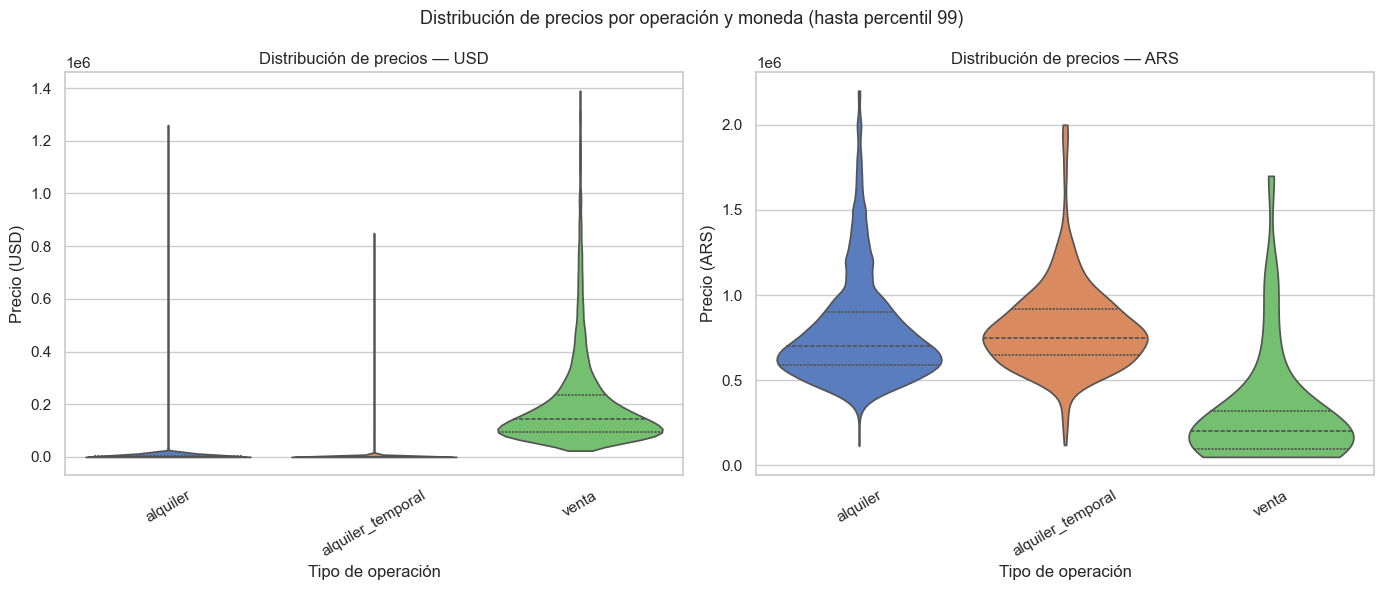

In [298]:
# Violin plot de precio_final por operación (separado por moneda)
# Usamos percentil 99 para limitar el eje y y que los outliers no distorsionen la visibilidad
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, moneda in zip(axes, ['usd', 'ars']):
    subset = df_final[
        df_final['moneda'] == moneda
    ][['operacion', 'precio']].dropna()
    
    # Limite por percentil 99 para cada segmento
    p99 = subset['precio'].quantile(0.99)
    subset = subset[subset['precio'] <= p99]
    
    sns.violinplot(data=subset, x='operacion', y='precio', ax=ax,
                   palette='muted', inner='quartile', cut=0)
    ax.set_title(f'Distribución de precios — {moneda.upper()}', fontsize=12)
    ax.set_xlabel('Tipo de operación')
    ax.set_ylabel(f'Precio ({moneda.upper()})')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Distribución de precios por operación y moneda (hasta percentil 99)', fontsize=13)
plt.tight_layout()
plt.show()

# 10. EDA - Análisis Bivariado y Multivariado

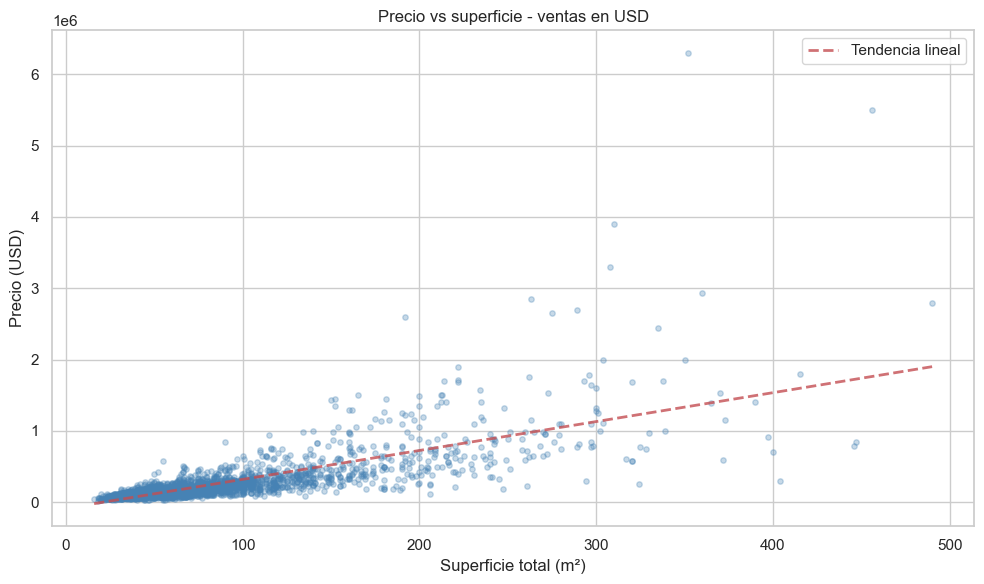

In [300]:
# Scatter de precio_final vs m2_total para ventas en USD
# Usamos una muestra aleatoria para evitar sobrecarga visual
subset_scatter = df_final[
    (df_final['moneda'] == 'usd') & 
    (df_final['operacion'] == 'venta') &
    df_final['precio'].notna() &
    df_final['m2_total'].notna() &
    (df_final['m2_total'] > 5) &
    (df_final['m2_total'] < 500)  # filtramos propiedades con m2 absurdo
].sample(min(3000, len(df_final)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    subset_scatter['m2_total'], 
    subset_scatter['precio'],
    alpha=0.3, s=15, color='steelblue'
)

# Línea de tendencia (regresión simple para orientación visual)
z = np.polyfit(subset_scatter['m2_total'].dropna(), 
               subset_scatter['precio'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(subset_scatter['m2_total'].min(), subset_scatter['m2_total'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Tendencia lineal')

ax.set_xlabel('Superficie total (m²)')
ax.set_ylabel('Precio (USD)')
ax.set_title('Precio vs superficie - ventas en USD')
ax.legend()
plt.tight_layout()
plt.show()

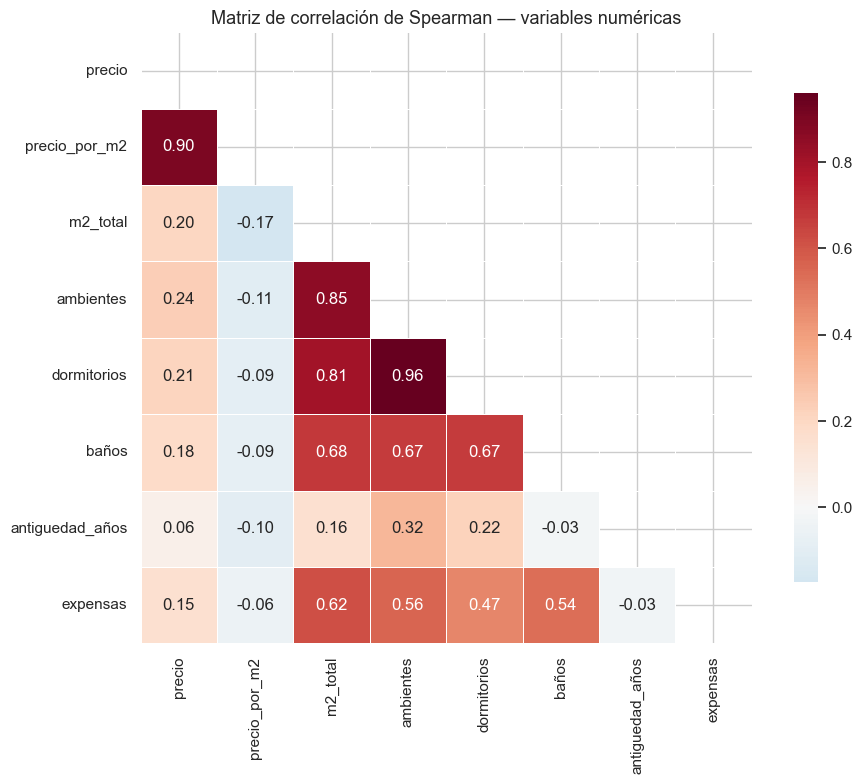

In [301]:
# Heatmap de correlación entre variables numéricas clave
# Usamos Spearman por la no-normalidad de las distribuciones de precio
vars_correlacion = [v for v in ['precio', 'precio_por_m2', 'm2_total', 
                                 'ambientes', 'dormitorios', 'baños', 
                                 'antiguedad_años', 'expensas'] 
                    if v in df_final.columns]

corr_matrix = df_final[vars_correlacion].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación de Spearman — variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# 11. Analisis geografico:

In [ ]:
import requests
import geopandas as gpd

# Descargamos el GeoJSON oficial de barrios de la Ciudad de Buenos Aires desde datos abiertos
url_geojson = "https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson"
geojson_barrios = requests.get(url_geojson).json()

nombres_geojson = {f["properties"]["nombre"] for f in geojson_barrios["features"]}

df_filtrado = df_final[df_final["barrio_oficial"].isin(nombres_geojson)]
conteo = df_filtrado.groupby("barrio_oficial").size().reset_index(name="cantidad")

nombres_df = set(conteo["barrio_oficial"])
print("Barrios sin coincidencia en el GeoJSON:", nombres_df - nombres_geojson)


Barrios sin coincidencia en el GeoJSON: set()


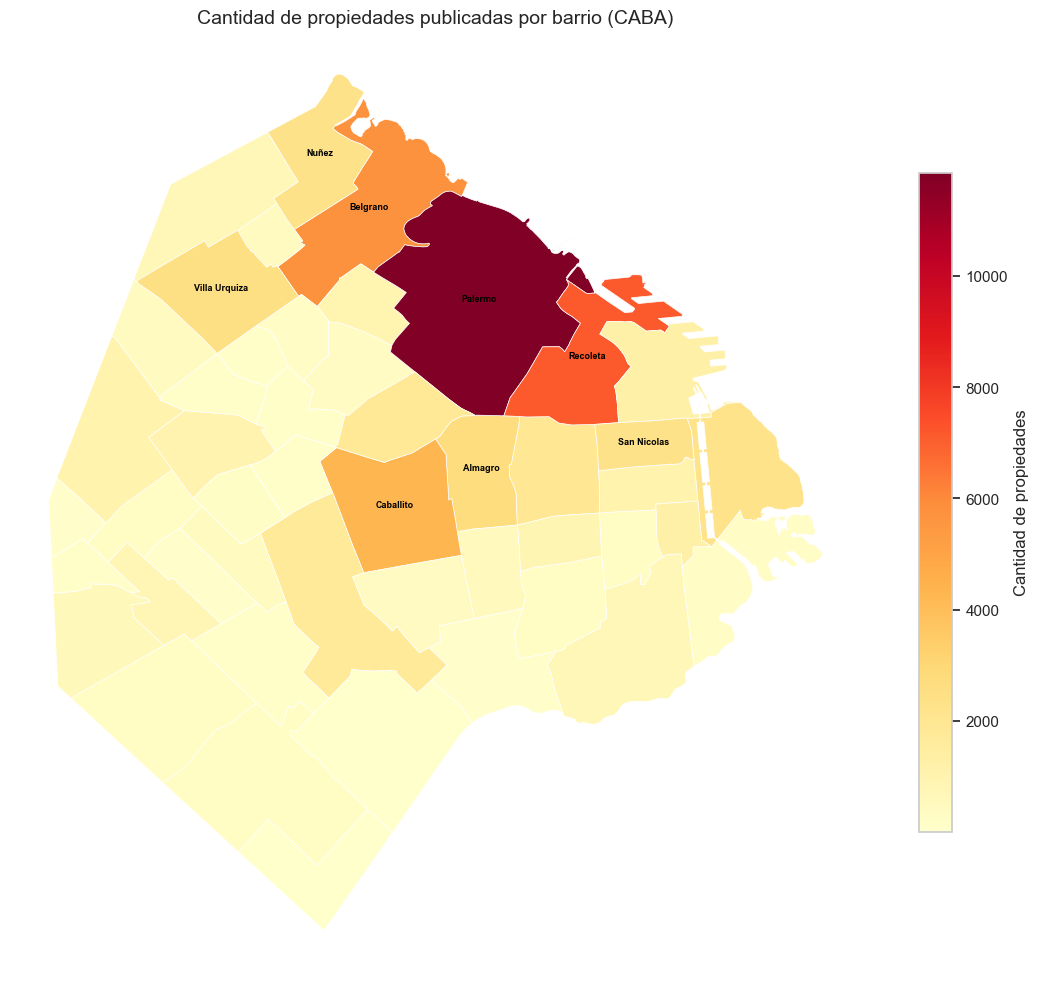

In [ ]:
# Construimos el GeoDataFrame de barrios y lo mergeamos con el conteo de propiedades
gdf = gpd.GeoDataFrame.from_features(geojson_barrios["features"])
gdf = gdf.rename(columns={"nombre": "barrio_oficial"})
gdf = gdf.set_crs("EPSG:4326")

gdf_conteo = gdf.merge(conteo, on="barrio_oficial", how="left")

# --- Mapa: cantidad de propiedades por barrio ---
fig, ax = plt.subplots(figsize=(12, 10))

gdf_conteo.plot(
    column="cantidad",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Cantidad de propiedades", "shrink": 0.7},
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
    ax=ax,
)

# Anotamos los top-8 barrios por cantidad
top_barrios = gdf_conteo.nlargest(8, "cantidad")
for _, row in top_barrios.iterrows():
    centroide = row.geometry.centroid
    ax.annotate(
        row["barrio_oficial"],
        xy=(centroide.x, centroide.y),
        ha="center",
        fontsize=6.5,
        color="black",
        fontweight="bold",
    )

ax.set_title("Cantidad de propiedades publicadas por barrio (CABA)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


Como se puede ver en el mapa, los barrios de Palermo, Belgrano, Recoleta y Caballito son los más representados en las bases de datos.

## Análisis geoespacial de precios por barrio

A continuación se presentan mapas coropléticos del precio mediano por barrio, separados por tipo de operación y moneda. Usamos la columna `precio` (ya limpia de texto) del DataFrame principal. Para venta e inmuebles con precio disponible se calcula también el precio mediano por m².

In [ ]:
def graficar_mapa_precio(gdf_base, df_source, filtro_operacion, filtro_moneda,
                          columna_precio, titulo, etiqueta_leyenda,
                          cmap="Blues", top_n=8, fmt_precio="{:,.0f}"):
    """
    Genera un mapa coroplético de precio mediano por barrio usando geopandas + matplotlib.

    Parámetros
    ----------
    gdf_base           : GeoDataFrame con la geometría de los barrios (columna 'barrio_oficial')
    df_source          : DataFrame con columnas barrio_oficial, operacion, moneda y columna_precio
    filtro_operacion   : str, valor de la columna 'operacion' a filtrar
    filtro_moneda      : str, valor de la columna 'moneda' a filtrar
    columna_precio     : str, columna numérica a agregar con la mediana
    titulo             : str, título del mapa
    etiqueta_leyenda   : str, etiqueta de la barra de colores
    cmap               : str, colormap de matplotlib
    top_n              : int, cantidad de barrios a anotar
    fmt_precio         : str, formato para el texto de anotación
    """
    # Filtrado y cálculo de mediana por barrio
    mask = (
        (df_source["operacion"] == filtro_operacion)
        & (df_source["moneda"] == filtro_moneda)
        & df_source[columna_precio].notna()
        & (df_source[columna_precio] > 0)
        & df_source["barrio_oficial"].notna()
    )
    estadisticas = (
        df_source[mask]
        .groupby("barrio_oficial")[columna_precio]
        .median()
        .reset_index()
        .rename(columns={columna_precio: "precio_mediano"})
    )

    gdf_merge = gdf_base.merge(estadisticas, on="barrio_oficial", how="left")

    fig, ax = plt.subplots(figsize=(12, 10))

    gdf_merge.plot(
        column="precio_mediano",
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=True,
        legend_kwds={"label": etiqueta_leyenda, "shrink": 0.7},
        missing_kwds={"color": "lightgray", "label": "Sin datos"},
        ax=ax,
    )

    # Anotamos los top-N barrios con mayor precio mediano
    top = gdf_merge.dropna(subset=["precio_mediano"]).nlargest(top_n, "precio_mediano")
    for _, row in top.iterrows():
        centroide = row.geometry.centroid
        ax.annotate(
            row["barrio_oficial"],
            xy=(centroide.x, centroide.y),
            ha="center",
            fontsize=6,
            color="black",
            fontweight="bold",
        )

    ax.set_title(titulo, fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


In [ ]:
# df_geo: registros con barrio_oficial válido para análisis geoespacial
# Nota: m2_total y precio_por_m2 solo estarán disponibles si la sección de
# parseo de detalles/descripción ya fue ejecutada previamente.
df_geo = df_filtrado.copy()

if "m2_total" in df.columns:
    df_geo["m2_total"] = df.loc[df_geo.index, "m2_total"]
    mask_m2 = df_geo["m2_total"].notna() & (df_geo["m2_total"] > 5) & df_geo["precio"].notna() & (df_geo["precio"] > 0)
    df_geo.loc[mask_m2, "precio_por_m2"] = df_geo.loc[mask_m2, "precio"] / df_geo.loc[mask_m2, "m2_total"]
    print(f"Registros con precio_por_m2 calculado: {mask_m2.sum():,}")
else:
    print("m2_total aún no disponible (ejecutar sección de parseo de detalles primero).")

print(f"Registros en df_geo: {len(df_geo):,}")
print(df_geo[["operacion", "moneda"]].value_counts())


m2_total aún no disponible (ejecutar sección de parseo de detalles primero).
Registros en df_geo: 62,830
operacion          moneda
venta              usd       33124
alquiler           ars       14455
                   usd        6875
alquiler_temporal  usd        6064
                   ars        2069
venta              ars         243
Name: count, dtype: int64


### Precio mediano de venta (USD) por barrio

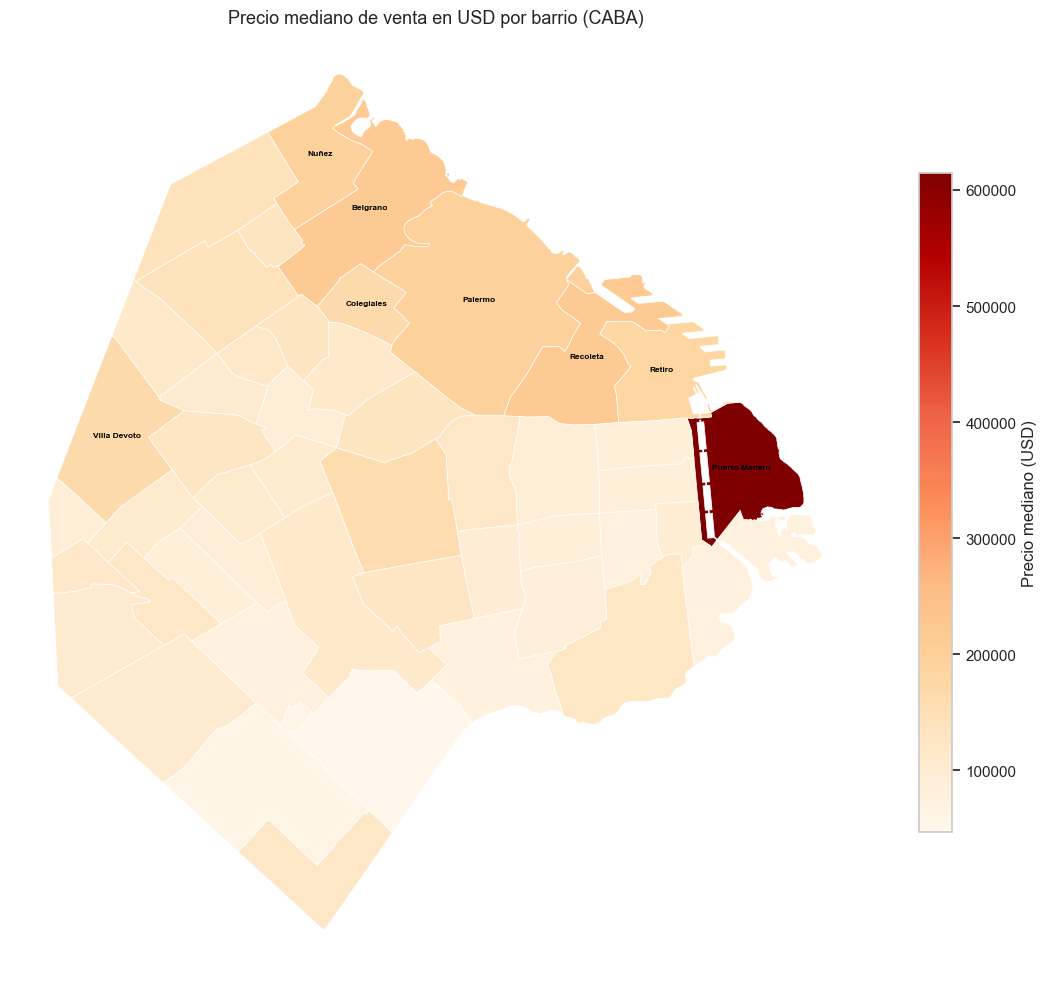

In [ ]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="venta",
    filtro_moneda="usd",
    columna_precio="precio",
    titulo="Precio mediano de venta en USD por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (USD)",
    cmap="OrRd",
    top_n=8,
)


### Precio mediano de alquiler (ARS) por barrio

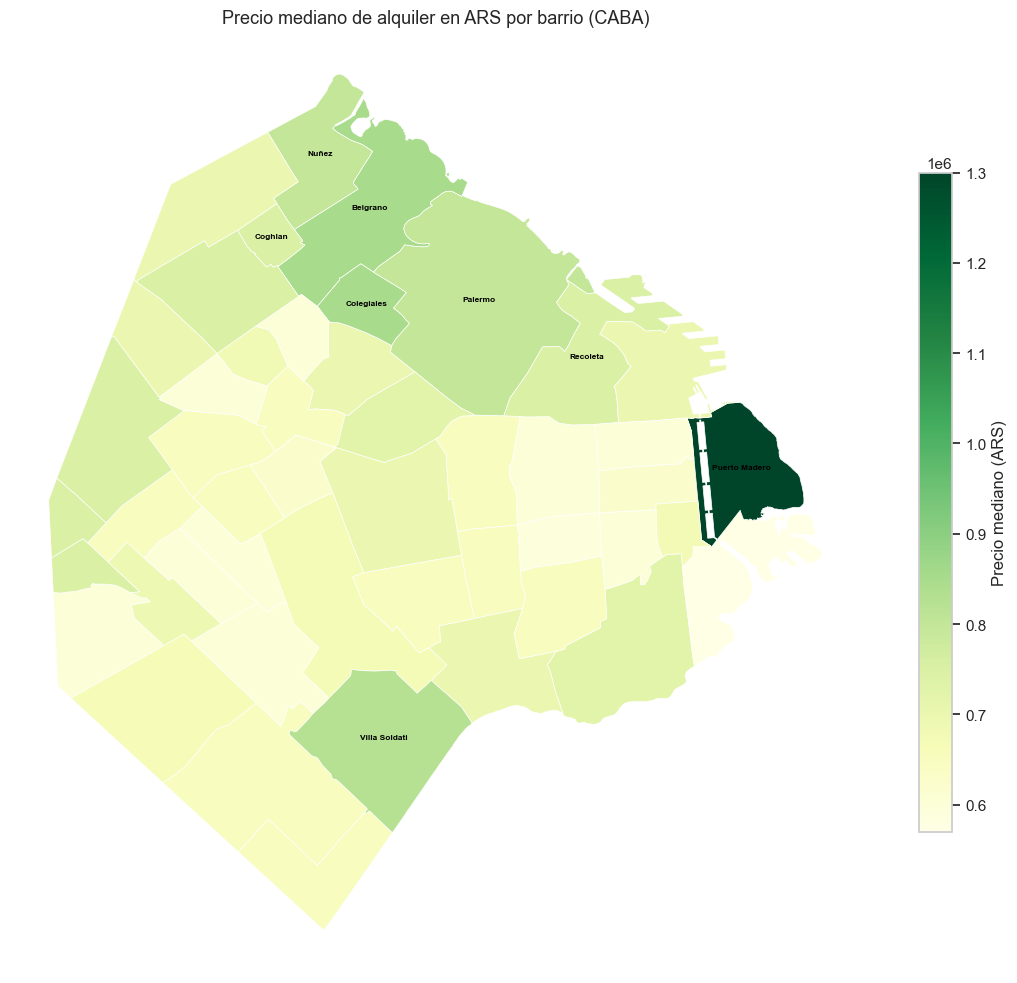

In [ ]:
graficar_mapa_precio(
    gdf_base=gdf,
    df_source=df_geo,
    filtro_operacion="alquiler",
    filtro_moneda="ars",
    columna_precio="precio",
    titulo="Precio mediano de alquiler en ARS por barrio (CABA)",
    etiqueta_leyenda="Precio mediano (ARS)",
    cmap="YlGn",
    top_n=8,
)


### Precio mediano por m² en venta (USD) por barrio

Este mapa muestra el precio mediano por metro cuadrado para propiedades en venta con precio en dólares. La columna `m2_total` proviene del parseo de la columna `detalles` (superficie total o cubierta). Solo se incluyen propiedades con `m2_total > 5 m²`.

In [ ]:
if "precio_por_m2" in df_geo.columns:
    graficar_mapa_precio(
        gdf_base=gdf,
        df_source=df_geo,
        filtro_operacion="venta",
        filtro_moneda="usd",
        columna_precio="precio_por_m2",
        titulo="Precio mediano por m² en venta USD por barrio (CABA)",
        etiqueta_leyenda="Precio mediano por m² (USD/m²)",
        cmap="RdPu",
        top_n=8,
    )
else:
    print("No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.")
    print("Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.")


No se pudo generar el mapa: la columna 'precio_por_m2' no está disponible.
Asegurate de ejecutar la celda de parseo de 'detalles' antes de esta.


In [ ]:
tabla_barrio_operacion = (
    df.groupby(["barrio_oficial", "operacion"])
      .size()
      .unstack(fill_value=0)
)

tabla_barrio_operacion["Total_barrio"] = tabla_barrio_operacion.sum(axis=1)
tabla_barrio_operacion.loc["Total_operacion"] = tabla_barrio_operacion.sum(axis=0)

tabla_barrio_operacion

operacion,alquiler,alquiler_temporal,venta,Total_barrio
barrio_oficial,,,,
Agronomia,30,1,92,123
Almagro,805,412,1446,2663
Balvanera,621,195,1156,1972
Barracas,220,15,488,723
Belgrano,1812,604,3322,5738
Boedo,175,15,352,542
Caballito,1500,239,2567,4306
Chacarita,122,41,203,366
Coghlan,96,26,311,433


La cantidad mínima de propiedades de los barrios se encuentra en Villa Riachuelo, con 5 propiedades. Asimismo, la operación con la menor cantidad de propiedades disponibles es 'alquiler_temporal'. Por ende, esperamos que las conclusiones más robustas del análisis sean sobre los barrios con mayor cantidad de propiedades (como los mencionados previamente), pero esperamos obtener conclusiones fuertes sobre los tres tipos de operaciones ya que 'alquiler_temporal' siendo la columna con la menor cantidad de filas presenta más de 8000 de las mismas.

# 12. Inferencia Estadística - Validación de Hipótesis

Transitamos de la exploración visual a la confirmación formal. Para cada hipótesis documentamos:
- **H₀** (hipótesis nula)
- **Estadístico y p-valor**
- **Decisión** (rechazar o no rechazar H₀ con α = 0.05)

In [302]:
from scipy.stats import chi2_contingency, f_oneway, spearmanr

# --- TEST 1: Chi-cuadrado ---
# H₀: el tipo de operación y tener cochera son variables independientes
# H₁: existe asociación entre el tipo de operación y la presencia de cochera

tabla_contingencia = pd.crosstab(df_final['operacion'], df_final['cochera'])
chi2, p_chi2, dof, expected = chi2_contingency(tabla_contingencia)

print("=== TEST 1: Chi-cuadrado — operación vs cochera ===")
print(f"\nTabla de contingencia:")
print(tabla_contingencia)
print(f"\nEstadístico χ² = {chi2:.2f}")
print(f"Grados de libertad = {dof}")
print(f"p-valor = {p_chi2:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_chi2 < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_chi2 < 0.05:
    print("  Conclusión: existe asociación estadísticamente significativa entre el")
    print("  tipo de operación y la presencia de cochera.")

=== TEST 1: Chi-cuadrado — operación vs cochera ===

Tabla de contingencia:
cochera                0      1
operacion                      
alquiler           14268   4302
alquiler_temporal   4855    803
venta              18588  10262

Estadístico χ² = 1515.74
Grados de libertad = 2
p-valor = 0.0000e+00

→ Rechazamos H₀ (α = 0.05)
  Conclusión: existe asociación estadísticamente significativa entre el
  tipo de operación y la presencia de cochera.


In [303]:
# --- TEST 2: ANOVA de un factor ---
# H₀: el precio_por_m2 promedio es igual en los top-5 barrios (ventas USD)
# H₁: al menos un barrio tiene media diferente

top5_barrios = (
    df_final[
        (df_final['operacion'] == 'venta') & 
        (df_final['moneda'] == 'usd') &
        df_final['precio_por_m2'].notna()
    ]
    .groupby('barrio_oficial')['precio_por_m2']
    .count()
    .nlargest(5)
    .index.tolist()
)

grupos = [
    df_final[
        (df_final['barrio_oficial'] == b) & 
        (df_final['operacion'] == 'venta') & 
        (df_final['moneda'] == 'usd')
    ]['precio_por_m2'].dropna().values
    for b in top5_barrios
]

f_stat, p_anova = f_oneway(*grupos)

print("=== TEST 2: ANOVA — precio/m² entre top-5 barrios (venta USD) ===")
print(f"\nBarrios analizados: {top5_barrios}")
for barrio, grupo in zip(top5_barrios, grupos):
    print(f"  {barrio:25s}: n={len(grupo):,}, mediana={np.median(grupo):,.0f} USD/m²")
print(f"\nEstadístico F = {f_stat:.2f}")
print(f"p-valor = {p_anova:.4e}")
print(f"\n→ {'Rechazamos H₀' if p_anova < 0.05 else 'No rechazamos H₀'} (α = 0.05)")
if p_anova < 0.05:
    print("  Conclusión: el precio por m² difiere significativamente entre barrios.")
    print("  La ubicación geográfica es un factor con impacto estadístico en el precio.")

=== TEST 2: ANOVA — precio/m² entre top-5 barrios (venta USD) ===

Barrios analizados: ['Palermo', 'Belgrano', 'Recoleta', 'Caballito', 'Villa Urquiza']
  Palermo                  : n=4,305, mediana=3,246 USD/m²
  Belgrano                 : n=2,821, mediana=3,118 USD/m²
  Recoleta                 : n=2,722, mediana=2,635 USD/m²
  Caballito                : n=2,226, mediana=2,394 USD/m²
  Villa Urquiza            : n=1,311, mediana=2,826 USD/m²

Estadístico F = 438.91
p-valor = 0.0000e+00

→ Rechazamos H₀ (α = 0.05)
  Conclusión: el precio por m² difiere significativamente entre barrios.
  La ubicación geográfica es un factor con impacto estadístico en el precio.


In [304]:
# --- TEST 3: Correlación de Spearman ---
# Relación entre precio_por_m2 y variables estructurales de la propiedad

variables_test = ['ambientes', 'dormitorios', 'baños', 'antiguedad_años']

print("=== TEST 3: Correlación de Spearman — precio/m² vs atributos de la propiedad ===")
print(f"{'Variable':20s}  {'ρ Spearman':>12s}  {'p-valor':>12s}  Decisión")
print("-" * 65)

for var in variables_test:
    if var not in df_final.columns:
        continue
    mask_valid = df_final['precio_por_m2'].notna() & df_final[var].notna()
    if mask_valid.sum() < 30:
        continue
    rho, p_val = spearmanr(
        df_final.loc[mask_valid, 'precio_por_m2'],
        df_final.loc[mask_valid, var]
    )
    decision = "Rechazar H₀" if p_val < 0.05 else "No rechazar H₀"
    print(f"{var:20s}  {rho:>12.4f}  {p_val:>12.4e}  {decision}")

print("\nH₀ en cada test: no existe correlación (ρ = 0)")
print("α = 0.05")

=== TEST 3: Correlación de Spearman — precio/m² vs atributos de la propiedad ===
Variable                ρ Spearman       p-valor  Decisión
-----------------------------------------------------------------
ambientes                  -0.1052    1.8173e-65  Rechazar H₀
dormitorios                -0.0925    8.1246e-81  Rechazar H₀
baños                      -0.0862    4.4437e-56  Rechazar H₀
antiguedad_años            -0.1028    2.4971e-54  Rechazar H₀

H₀ en cada test: no existe correlación (ρ = 0)
α = 0.05
